# AFM shot-study figures for $N=5$

This notebook only loads existing `.npz` results and draws figures. Each output figure has its own editable code cell. All training-derived data use $N_y=100$ output shots per epoch. The gradient-distribution scans instead use the exact ground-state output expectation, so they have no finite-$N_y$ output sampling.


In [66]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

_candidates = [
    Path.cwd(),
    Path.cwd() / "QEP_multiple_shot" / "AFM_searching",
]
STUDY_DIR = next(
    path.resolve()
    for path in _candidates
    if (path / "shot_study" / "config.py").exists()
)
WORKSPACE = STUDY_DIR.parents[1]
DATA_DIR = STUDY_DIR / "data" / "shots_2026-09-11"
FIG_DIR = STUDY_DIR / "figures" / "shots_2026-09-11"
PHASE_DIR = WORKSPACE / "AFM_searching" / "data" / "phase"
FIG_DIR.mkdir(parents=True, exist_ok=True)

N = 5
N_Y = 100  # output shots per training epoch
NG_GRID = (10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000)
TRAJECTORY_NG = (10, 100, 1000, 10000)
SHOT_BUDGETS = (5000, 10000, 20000, 50000, 100000)
BUDGET_SEEDS = 5
PARAM_LABELS = (r"$g_\Omega$", r"$g_\Delta$")
COLORS = plt.get_cmap("viridis")(np.linspace(0.08, 0.92, len(NG_GRID)))

def load(path):
    return np.load(path, allow_pickle=False)

def save_show(fig, stem):
    for suffix in (".pdf", ".png"):
        kwargs = {"dpi": 180} if suffix == ".png" else {}
        fig.savefig(FIG_DIR / f"{stem}{suffix}", bbox_inches="tight", **kwargs)
        print("Saved as", FIG_DIR / f"{stem}{suffix}")
    plt.show()

def finish(ax, xlabel, ylabel, title=None, legend=True):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(alpha=0.22)
    if legend:
        ax.legend(frameon=False, fontsize=8)

def trajectory_files(N_g):
    return sorted(
        path
        for path in (DATA_DIR / "trajectories").glob(
            f"N{N}_init*_Ng{N_g}_seed*.npz"
        )
        if "_smoke" not in path.stem
    )

def load_budget_matrix():
    records = {}
    for N_g in NG_GRID:
        files = sorted(
            path
            for path in (DATA_DIR / "budgets").glob(
                f"N{N}_Ng{N_g}_seed*.npz"
            )
            if "_smoke" not in path.stem
        )
        if len(files) != BUDGET_SEEDS:
            raise RuntimeError(
                f"N={N}, N_g={N_g}: found {len(files)}/{BUDGET_SEEDS} runs"
            )
        records[N_g] = np.stack([
            load(path)["checkpoint_exact_AM2"] for path in files
        ])

    means = []
    for N_g in NG_GRID:
        values = records[N_g]
        counts = np.isfinite(values).sum(axis=0)
        mean = np.full(values.shape[1], np.nan)
        np.divide(
            np.nansum(values, axis=0), counts,
            out=mean, where=counts > 0
        )
        means.append(mean)
    return np.stack(means).T

print("Reading data from:", DATA_DIR)
print("Writing figures to:", FIG_DIR)
print(f"Training data use N_y={N_Y} output shots per epoch")

# Selected illustrative phase panels only; ensemble statistics are unchanged.
PHASE_INIT_IDS = (3, 5, 1)  # blue, orange, green
PHASE_COLORS = ("#174A78", "#B45309", "#166534")  # dark blue, burnt orange, forest green
PHASE_TRAJECTORY_EPOCHS = 200
OVERLAP_DIR = DATA_DIR / "trajectories_overlap_2026-09-14"

def phase_trajectory_files(N_g):
    files = []
    for init_id in PHASE_INIT_IDS:
        # Reuse the original five seeds for the replacement green start.
        directory = DATA_DIR / "trajectories" if init_id < 3 else OVERLAP_DIR
        for seed_id in range(5):
            path = directory / f"N{N}_init{init_id}_Ng{N_g}_seed{seed_id}.npz"
            with load(path) as data:
                meta = json.loads(str(data["metadata"]))
                assert (meta["N"], meta["N_g"], meta["N_y"], meta["init_id"], meta["seed_id"]) == (N, N_g, N_Y, init_id, seed_id)
                assert len(data["measured_AM2"]) >= PHASE_TRAJECTORY_EPOCHS
            files.append(path)
    return files


Reading data from: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/data/shots_2026-09-11
Writing figures to: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11
Training data use N_y=100 output shots per epoch


## 1. Gradient distributions versus shot count

The dashed black lines are exact gradient expectations evaluated from the exact ground state.


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_distribution_ng_N5.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_distribution_ng_N5.png


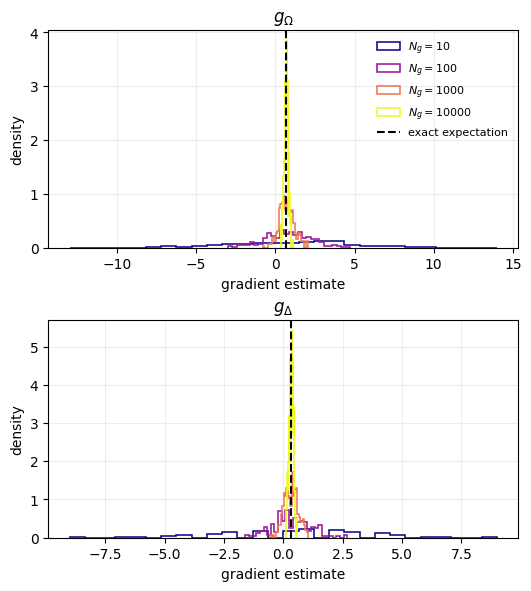

In [67]:
d = load(DATA_DIR / f"gradient_ng_N{N}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]
shown = [
    i for i, value in enumerate(values)
    if int(value) in TRAJECTORY_NG
]

fig, axes = plt.subplots(
    2, 1, figsize=(5.2, 5.8), layout="constrained"
)
for p, ax in enumerate(axes):
    for i in shown:
        color = plt.get_cmap("plasma")(
            i / max(1, len(values) - 1)
        )
        ax.hist(
            gradients[i, :, p],
            bins=28,
            density=True,
            histtype="step",
            linewidth=1.15,
            color=color,
            label=rf"$N_g={int(values[i])}$",
        )

    if not np.allclose(
        exact[:, p], exact[0, p], rtol=1e-7, atol=1e-9
    ):
        raise RuntimeError(
            "The exact gradient unexpectedly depends on N_g"
        )
    ax.axvline(
        exact[0, p],
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="exact expectation",
    )
    finish(
        ax, "gradient estimate", "density",
        PARAM_LABELS[p], legend=(p == 0)
    )

save_show(fig, f"gradient_distribution_ng_N{N}")


## 2. Gradient distributions versus $\beta$

Each dotted line is the exact ground-state expectation at that $\beta$.


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_distribution_beta_N5.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_distribution_beta_N5.png


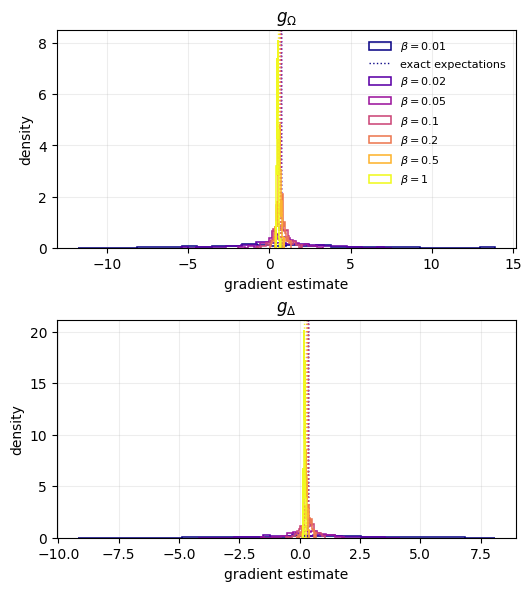

In [68]:
d = load(DATA_DIR / f"gradient_beta_N{N}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]

fig, axes = plt.subplots(
    2, 1, figsize=(5.2, 5.8), layout="constrained"
)
for p, ax in enumerate(axes):
    for i, value in enumerate(values):
        color = plt.get_cmap("plasma")(
            i / max(1, len(values) - 1)
        )
        ax.hist(
            gradients[i, :, p],
            bins=28,
            density=True,
            histtype="step",
            linewidth=1.15,
            color=color,
            label=rf"$\beta={value:g}$",
        )
        ax.axvline(
            exact[i, p],
            color=color,
            linestyle=":",
            linewidth=1.0,
            label="exact expectations" if i == 0 else None,
        )
    finish(
        ax, "gradient estimate", "density",
        PARAM_LABELS[p], legend=(p == 0)
    )

save_show(fig, f"gradient_distribution_beta_N{N}")


## 3. Gradient standard-deviation scaling


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_std_scaling_N5.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_std_scaling_N5.png


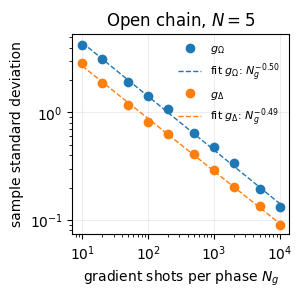

In [69]:
d = load(DATA_DIR / f"gradient_ng_N{N}.npz")
values = d["scan_values"]
std = d["gradients"].std(axis=1, ddof=1)

fig, ax = plt.subplots(figsize=(2.8, 2.6))
for p, label in enumerate(PARAM_LABELS):
    fit = np.polyfit(np.log(values), np.log(std[:, p]), 1)
    fitted_line = np.exp(fit[1]) * values ** fit[0]
    color = ("tab:blue", "tab:orange")[p]
    ax.loglog(values, std[:, p], "o", color=color, label=label)
    ax.loglog(
        values,
        fitted_line,
        "--",
        color=color,
        linewidth=1,
        label=rf"fit {label}: $N_g^{{{fit[0]:.2f}}}$",
    )
finish(
    ax,
    r"gradient shots per phase $N_g$",
    "sample standard deviation",
    rf"Open chain, $N={N}$",
)
save_show(fig, f"gradient_std_scaling_N{N}")


## 4. $\beta$ noise–bias tradeoff, $N_g=1000$

Exact ground-state output; no finite-$N_y$ sampling. RMSE uses the exact gradient at the smallest sampled $\beta$ as its reference.


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_beta_tradeoff_N5.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_beta_tradeoff_N5.png


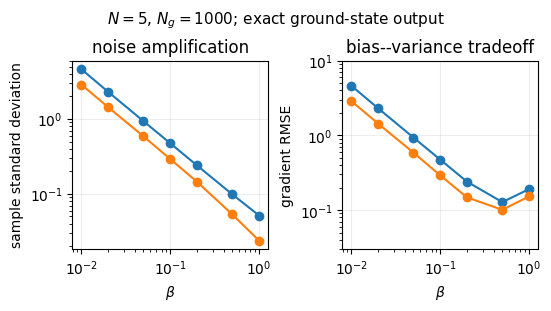

In [70]:
N_g = 1000  # fixed gradient shots per phase
d = load(DATA_DIR / f"gradient_beta_N{N}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]
std = gradients.std(axis=1, ddof=1)
reference = exact[0]
rmse = np.sqrt(
    ((gradients - reference[None, None, :]) ** 2).mean(axis=1)
)

fig, axes = plt.subplots(
    1, 2, figsize=(5.4, 3.0), layout="constrained"
)
for p, label in enumerate(PARAM_LABELS):
    axes[0].loglog(values, std[:, p], "o-", label=label)
    axes[1].loglog(values, rmse[:, p], "o-", label=label)
    axes[1].set_ylim(0.03, 10)
finish(
    axes[0],
    r"$\beta$",
    "sample standard deviation",
    "noise amplification",
    legend=False
)
finish(
    axes[1],
    r"$\beta$",
    "gradient RMSE",
    "bias--variance tradeoff",
    legend=False
)

#axes[1].legend(fontsize=12)

fig.suptitle(rf"$N={N}$, $N_g={N_g}$; exact ground-state output", fontsize=11)
save_show(fig, f"gradient_beta_tradeoff_N{N}")


## 4a. $\beta$ noise–bias tradeoff, $N_g=10$

256 repetitions per $\beta$, using the exact ground-state output expectation.
RMSE is relative to the exact gradient at the smallest sampled $\beta=0.01$.


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_beta_tradeoff_N5_Ng10.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_beta_tradeoff_N5_Ng10.png


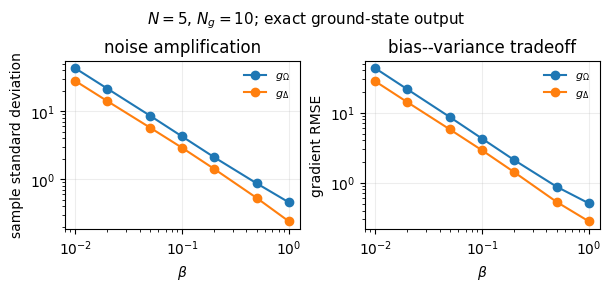

In [71]:
N_g = 10  # fixed gradient shots per phase
d = load(DATA_DIR / f"gradient_beta_N{N}_Ng{N_g}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]
std = gradients.std(axis=1, ddof=1)
reference = exact[0]
rmse = np.sqrt(
    ((gradients - reference[None, None, :]) ** 2).mean(axis=1)
)

fig, axes = plt.subplots(
    1, 2, figsize=(6.0, 2.8), layout="constrained"
)
for p, label in enumerate(PARAM_LABELS):
    axes[0].loglog(values, std[:, p], "o-", label=label)
    axes[1].loglog(values, rmse[:, p], "o-", label=label)
finish(
    axes[0],
    r"$\beta$",
    "sample standard deviation",
    "noise amplification",
)
finish(
    axes[1],
    r"$\beta$",
    "gradient RMSE",
    "bias--variance tradeoff",
)
fig.suptitle(rf"$N={N}$, $N_g={N_g}$; exact ground-state output", fontsize=11)
save_show(fig, f"gradient_beta_tradeoff_N{N}_Ng{N_g}")


## 4b. $\beta$ noise–bias tradeoff, $N_g=100$

256 repetitions per $\beta$, using the exact ground-state output expectation.
RMSE is relative to the exact gradient at the smallest sampled $\beta=0.01$.


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_beta_tradeoff_N5_Ng100.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_beta_tradeoff_N5_Ng100.png


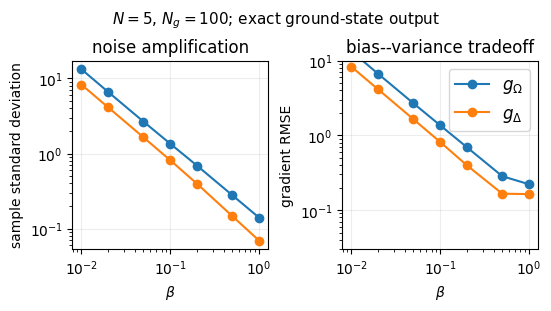

In [72]:
N_g = 100  # fixed gradient shots per phase
d = load(DATA_DIR / f"gradient_beta_N{N}_Ng{N_g}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]
std = gradients.std(axis=1, ddof=1)
reference = exact[0]
rmse = np.sqrt(
    ((gradients - reference[None, None, :]) ** 2).mean(axis=1)
)

fig, axes = plt.subplots(
    1, 2, figsize=(5.4, 3.0), layout="constrained"
)
for p, label in enumerate(PARAM_LABELS):
    axes[0].loglog(values, std[:, p], "o-", label=label)
    axes[1].loglog(values, rmse[:, p], "o-", label=label)
    axes[1].set_ylim(0.03, 10)
finish(
    axes[0],
    r"$\beta$",
    "sample standard deviation",
    "noise amplification",
    legend=False
)
finish(
    axes[1],
    r"$\beta$",
    "gradient RMSE",
    "bias--variance tradeoff",
    legend=False
)

axes[1].legend(fontsize=12)
fig.suptitle(rf"$N={N}$, $N_g={N_g}$; exact ground-state output", fontsize=11)
save_show(fig, f"gradient_beta_tradeoff_N{N}_Ng{N_g}")


## 4c. $\beta$ noise–bias tradeoff, $N_g=10000$

256 repetitions per $\beta$, using the exact ground-state output expectation.
RMSE is relative to the exact gradient at the smallest sampled $\beta=0.01$.


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_beta_tradeoff_N5_Ng10000.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_beta_tradeoff_N5_Ng10000.png


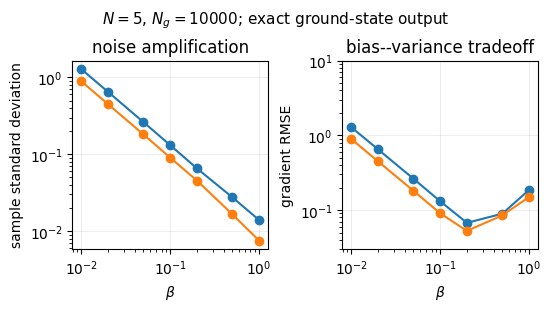

In [73]:
N_g = 10000  # fixed gradient shots per phase
d = load(DATA_DIR / f"gradient_beta_N{N}_Ng{N_g}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]
std = gradients.std(axis=1, ddof=1)
reference = exact[0]
rmse = np.sqrt(
    ((gradients - reference[None, None, :]) ** 2).mean(axis=1)
)

fig, axes = plt.subplots(
    1, 2, figsize=(5.4, 3.0), layout="constrained"
)
for p, label in enumerate(PARAM_LABELS):
    axes[0].loglog(values, std[:, p], "o-", label=label)
    axes[1].loglog(values, rmse[:, p], "o-", label=label)
    axes[1].set_ylim(0.03, 10)
finish(
    axes[0],
    r"$\beta$",
    "sample standard deviation",
    "noise amplification",
    legend=False
)
finish(
    axes[1],
    r"$\beta$",
    "gradient RMSE",
    "bias--variance tradeoff",
    legend=False
)

#axes[1].legend(fontsize=12)
fig.suptitle(rf"$N={N}$, $N_g={N_g}$; exact ground-state output", fontsize=11)
save_show(fig, f"gradient_beta_tradeoff_N{N}_Ng{N_g}")


## 5. Phase trajectories for $N_g=10$

Selected illustrative starts **3, 5, 1** (blue, orange, green) have
$(\Omega,\Delta)=(0.390736,1.166490)$, $(1.167713,1.085347)$, and
$(0.695463,1.955666)$. The green start replaces start 8, previously
$(0.935123,2.467223)$. This is a performance-informed illustrative choice;
the ten-start statistical ensemble is unchanged.

Each colored line is **one actual sampling seed**: all five seeds are shown
for every start, with **no mean path or mean endpoint**. Circles mark common
initial parameters and squares mark individual parameters after **200 updates**.
Edit `seed_alpha`, `seed_lw`, and `PHASE_COLORS` for appearance.

The dashed background contour marks exact ground-state
$\langle AFM^2\rangle=0.9$; it is a reference level, not a phase boundary.
At $N_g=10000$, the five replacement-green endpoints have exact
$\langle AFM^2\rangle=0.949$--$0.971$ (mean $0.960$), whereas the old green
start gave a mean of $0.312$. The replacement endpoints are near
$(\Delta,\Omega)=(1.52,0.16)$, compared with roughly $(1.83,0.88)$ before.
These endpoints reach high order, not exactly the maximum value 1.


In [74]:
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects

def draw_phase_paths(ax, N_g, seed_alpha=1.0, seed_lw=0.75,
                     path_colors=None, outline_width=0.0, output_suffix=""):
    """Show all five actual seed paths per start; no mean path or mean endpoint."""
    grouped = {init_id: [] for init_id in PHASE_INIT_IDS}
    for path in phase_trajectory_files(N_g):
        with load(path) as data:
            meta = json.loads(str(data["metadata"]))
            path_xy = np.column_stack([
                data["Delta"][:PHASE_TRAJECTORY_EPOCHS + 1],
                data["Omega"][:PHASE_TRAJECTORY_EPOCHS + 1],
            ])
        assert path_xy.shape == (PHASE_TRAJECTORY_EPOCHS + 1, 2)
        assert np.isfinite(path_xy).all()
        grouped[meta["init_id"]].append(path_xy)

    for color_id, init_id in enumerate(PHASE_INIT_IDS):
        paths = np.stack(grouped[init_id])
        assert paths.shape[0] == 5
        np.testing.assert_allclose(paths[:, 0], np.broadcast_to(paths[0, 0], (5, 2)))
        color = (PHASE_COLORS if path_colors is None else path_colors)[color_id]
        for xy in paths:
            line, = ax.plot(xy[:, 0], xy[:, 1], color=color, lw=seed_lw,
                            alpha=seed_alpha, zorder=3)
            if outline_width > 0:
                line.set_path_effects([
                    path_effects.Stroke(linewidth=seed_lw + outline_width, foreground="white"),
                    path_effects.Normal(),
                ])
        ax.scatter(paths[:, -1, 0], paths[:, -1, 1], marker="s", s=22,
                   facecolors=color, edgecolors="white", linewidths=0.6,
                   alpha=0.9, zorder=4)
        # The five seeds share this initial point; draw its marker once.
        ax.plot(paths[0, 0, 0], paths[0, 0, 1], "o", color=color,
                ms=5.5, mec="white", mew=0.9, zorder=5)

    # Same zoom in every panel; includes all seeds at all four N_g values.
    ax.set_xlim(-0.1, 2.25)
    ax.set_ylim(-0.75, 1.5)
    ax.legend(handles=[
        Line2D([], [], color="0.25", lw=seed_lw, label="Individual seeds"),
        Line2D([], [], color="0.25", ls="none", marker="o", ms=4, label="Start"),
        Line2D([], [], color="0.25", ls="none", marker="s", ms=4, label="End (200)"),
    ], bbox_to_anchor=(1., -0.5), ncol=3, fontsize=8,
       frameon=True, framealpha=0.9, edgecolor="none", columnspacing=0.8)

def draw_afm_contour(ax, phase):
    # A quantitative reference, not a claimed thermodynamic phase boundary.
    contour = ax.contour(phase["Delta_list"], phase["Omega_list"], phase["AM2"],
                         levels=[0.9], colors="0.3", linewidths=0.7,
                         linestyles="--", zorder=2)
    ax.clabel(contour, fmt={0.9: r"$\langle AFM^2\rangle=0.9$"},
              fontsize=8.5, inline=True, manual=[(0.6, -0.1)])

def plot_trajs(N_g, seed_alpha=0.45, seed_lw=0.75, figsize=(3.8, 3.3), cmap="Reds",
               path_colors=None, outline_width=0.0, output_suffix=""):
    phase = load(PHASE_DIR / f"phase_chain_N{N}.npz")
    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(
        phase["Delta_list"], phase["Omega_list"], phase["AM2"],
        shading="auto", cmap=cmap, vmin=0, vmax=1, alpha=0.7, rasterized=True,
    )
    draw_afm_contour(ax, phase)
    draw_phase_paths(ax, N_g, seed_alpha=seed_alpha, seed_lw=seed_lw,
                     path_colors=path_colors, outline_width=outline_width)
    fig.colorbar(mesh, ax=ax).set_label(r"exact ground-state $\langle AFM^2\rangle$")
    finish(ax, r"$\Delta$", r"$\Omega$",
           rf"$N={N}$, $N_g={N_g}$, $N_y={N_Y}$; 200 epochs", legend=False)
    #fig.legend(bbox_to_anchor=(0,-0.5))
    save_show(fig, f"phase_trajectories_N{N}_Ng{N_g}{output_suffix}")


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng10_cell62.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng10_cell62.png


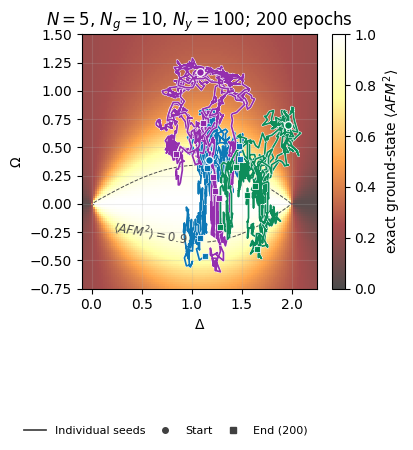

Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng100_cell62.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng100_cell62.png


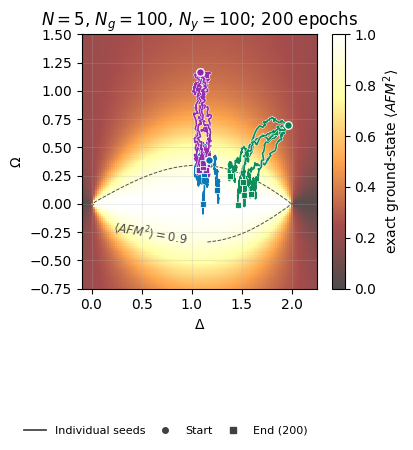

Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng1000_cell62.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng1000_cell62.png


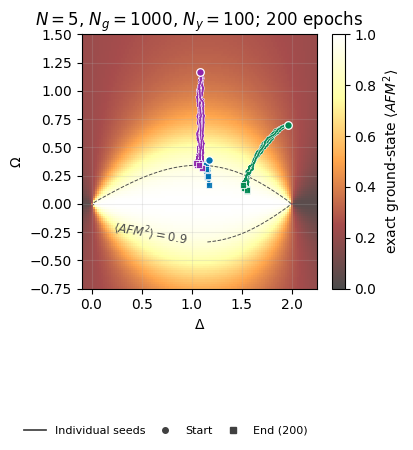

Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng10000_cell62.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng10000_cell62.png


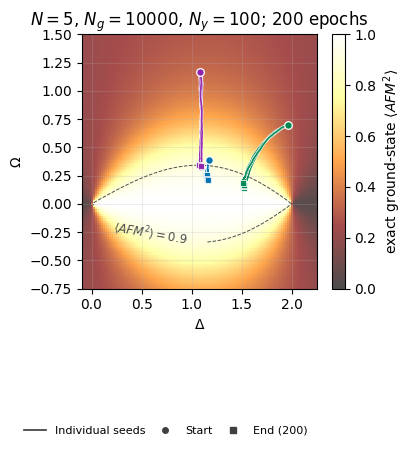

In [75]:
# Appearance only: preserve the afmhot background, size, axes, and legend layout.
trajectory_style = dict(
    seed_alpha=0.95,       # explicit here: avoids an older wrapper default
    seed_lw=1.25,         # thicker individual seed paths
    path_colors=("#0072B2", "#8E24AA", "#008751"),  # blue, purple, green
    outline_width=0.7,    # narrow white outline for contrast on dark regions
    output_suffix="_cell62",  # later figure cells cannot overwrite this layout
)
plot_trajs(N_g=10, cmap='afmhot', **trajectory_style)
plot_trajs(N_g=100, cmap='afmhot', **trajectory_style)
plot_trajs(N_g=1000, cmap='afmhot', **trajectory_style)
plot_trajs(N_g=10000, cmap='afmhot', **trajectory_style)


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng10.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng10.png


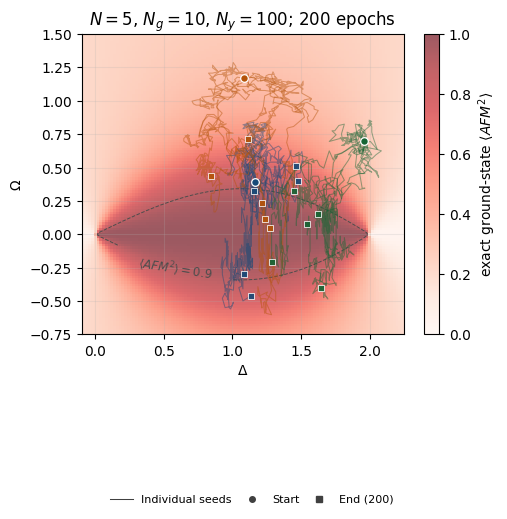

In [76]:
N_g = 10
phase = load(PHASE_DIR / f"phase_chain_N{N}.npz")
fig, ax = plt.subplots(figsize=(5.2, 3.9))
mesh = ax.pcolormesh(
    phase["Delta_list"],
    phase["Omega_list"],
    phase["AM2"],
    shading="auto",
    cmap="Reds",
    vmin=0,
    vmax=1,
    alpha=0.65,  # retain contrast while keeping seed paths readable
    rasterized=True,
)
# Adjust seed_alpha or seed_lw to edit the individual paths.
draw_afm_contour(ax, phase)
draw_phase_paths(ax, N_g, seed_alpha=0.45, seed_lw=0.75)
fig.colorbar(mesh, ax=ax).set_label(
    r"exact ground-state $\langle AFM^2\rangle$"
)
finish(
    ax,
    r"$\Delta$",
    r"$\Omega$",
    rf"$N={N}$, $N_g={N_g}$, $N_y={N_Y}$; 200 epochs",
    legend=False,
)
save_show(fig, f"phase_trajectories_N{N}_Ng{N_g}")


## 6. Phase trajectories for $N_g=100$


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng100.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng100.png


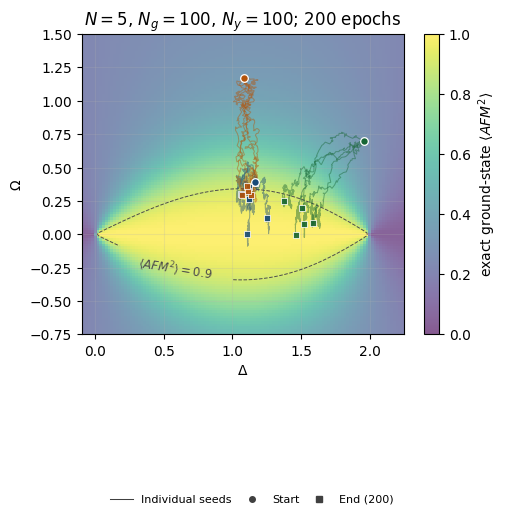

In [77]:
N_g = 100
phase = load(PHASE_DIR / f"phase_chain_N{N}.npz")
fig, ax = plt.subplots(figsize=(5.2, 3.9))
mesh = ax.pcolormesh(
    phase["Delta_list"],
    phase["Omega_list"],
    phase["AM2"],
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
    alpha=0.65,  # retain contrast while keeping seed paths readable
    rasterized=True,
)
# Adjust seed_alpha or seed_lw to edit the individual paths.
draw_afm_contour(ax, phase)
draw_phase_paths(ax, N_g, seed_alpha=0.45, seed_lw=0.75)
fig.colorbar(mesh, ax=ax).set_label(
    r"exact ground-state $\langle AFM^2\rangle$"
)
finish(
    ax,
    r"$\Delta$",
    r"$\Omega$",
    rf"$N={N}$, $N_g={N_g}$, $N_y={N_Y}$; 200 epochs",
    legend=False,
)
save_show(fig, f"phase_trajectories_N{N}_Ng{N_g}")


## 7. Phase trajectories for $N_g=1000$


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng1000.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/phase_trajectories_N5_Ng1000.png


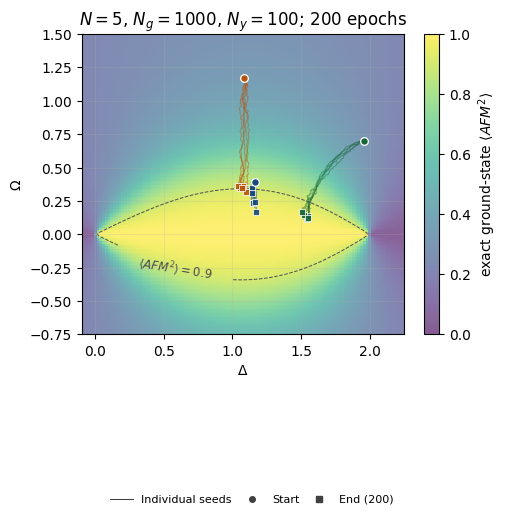

In [78]:
N_g = 1000
phase = load(PHASE_DIR / f"phase_chain_N{N}.npz")
fig, ax = plt.subplots(figsize=(5.2, 3.9))
mesh = ax.pcolormesh(
    phase["Delta_list"],
    phase["Omega_list"],
    phase["AM2"],
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
    alpha=0.65,  # retain contrast while keeping seed paths readable
    rasterized=True,
)
# Adjust seed_alpha or seed_lw to edit the individual paths.
draw_afm_contour(ax, phase)
draw_phase_paths(ax, N_g, seed_alpha=0.45, seed_lw=0.75)
fig.colorbar(mesh, ax=ax).set_label(
    r"exact ground-state $\langle AFM^2\rangle$"
)
finish(
    ax,
    r"$\Delta$",
    r"$\Omega$",
    rf"$N={N}$, $N_g={N_g}$, $N_y={N_Y}$; 200 epochs",
    legend=False,
)
save_show(fig, f"phase_trajectories_N{N}_Ng{N_g}")


## 8. Phase trajectories for $N_g=10000$

**Explicit green-start-1 version.** This cell is self-contained: it does not use
`PHASE_INIT_IDS`, `phase_trajectory_files`, `draw_phase_paths`, or `plot_trajs`
from a previous kernel execution. Run this cell directly after reopening the notebook.
It prints the exact files and five green endpoints it plots. The green start is
$(\Delta,\Omega)=(1.955666,0.695463)$, not $(2.467223,0.935123)$.
Only actual seed paths are drawn. The separately named `figure8_N5_green_init1`
exports make the updated figure identifiable independently of older exports.


FIGURE 8 — GREEN START 1 (individual paths, no means)
Reading from: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/data/shots_2026-09-11
Green seed 0: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/data/shots_2026-09-11/trajectories/N5_init1_Ng10000_seed0.npz
  endpoint (Delta, Omega) = (1.523876, 0.136273)
Green seed 1: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/data/shots_2026-09-11/trajectories/N5_init1_Ng10000_seed1.npz
  endpoint (Delta, Omega) = (1.510956, 0.158663)
Green seed 2: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/data/shots_2026-09-11/trajectories/N5_init1_Ng10000_seed2.npz
  endpoint (Delta, Omega) = (1.524196, 0.155803)
Green seed 3: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/data/shots_2026-09-11/trajectories/N5_init1_Ng10000_seed

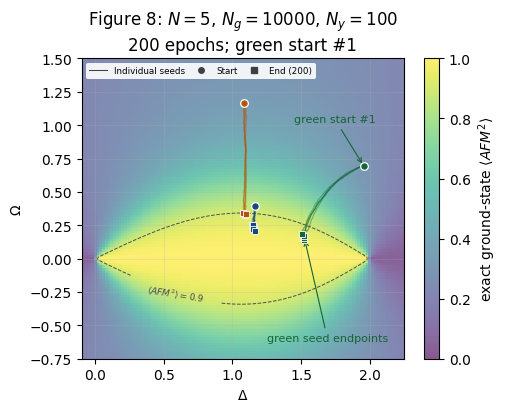

In [79]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Deliberately independent of every previously defined notebook plotting helper.
fig8_candidates = [Path.cwd(), Path.cwd() / "QEP_multiple_shot" / "AFM_searching"]
fig8_study = next(p.resolve() for p in fig8_candidates if (p / "shot_study" / "config.py").exists())
fig8_data = fig8_study / "data" / "shots_2026-09-11"
fig8_output = fig8_study / "figures" / "shots_2026-09-11"
fig8_phase = fig8_study.parents[1] / "AFM_searching" / "data" / "phase" / "phase_chain_N5.npz"
fig8_starts = (3, 5, 1)  # explicitly blue, orange, GREEN START 1
fig8_colors = ("#174A78", "#B45309", "#166534")
fig8_epochs = 200
fig8_ng = 10000
fig8_seed_alpha = 0.45
fig8_seed_lw = 0.75

print("FIGURE 8 — GREEN START 1 (individual paths, no means)")
print("Reading from:", fig8_data)
with np.load(fig8_phase, allow_pickle=False) as fig8_background:
    fig8_om_grid = fig8_background["Omega_list"]
    fig8_de_grid = fig8_background["Delta_list"]
    fig8_am2 = fig8_background["AM2"]

fig8_fig, fig8_ax = plt.subplots(figsize=(5.2, 3.9))
fig8_mesh = fig8_ax.pcolormesh(fig8_de_grid, fig8_om_grid, fig8_am2,
                             shading="auto", cmap="viridis", vmin=0, vmax=1,
                             alpha=0.65, rasterized=True)
fig8_contour = fig8_ax.contour(fig8_de_grid, fig8_om_grid, fig8_am2, levels=[0.9],
                             colors="0.3", linewidths=0.7, linestyles="--")
fig8_ax.clabel(fig8_contour, fmt={0.9: r"$\langle AFM^2\rangle=0.9$"},
              fontsize=6.5, manual=[(0.6, -0.1)])
fig8_green = []
for fig8_init, fig8_color in zip(fig8_starts, fig8_colors):
    fig8_directory = (fig8_data / "trajectories" if fig8_init == 1
                      else fig8_data / "trajectories_overlap_2026-09-14")
    for fig8_seed in range(5):
        fig8_path = fig8_directory / f"N5_init{fig8_init}_Ng{fig8_ng}_seed{fig8_seed}.npz"
        with np.load(fig8_path, allow_pickle=False) as fig8_run:
            fig8_meta = json.loads(str(fig8_run["metadata"]))
            assert (fig8_meta["N"], fig8_meta["N_g"], fig8_meta["N_y"], fig8_meta["init_id"], fig8_meta["seed_id"]) == (5, fig8_ng, 100, fig8_init, fig8_seed)
            fig8_xy = np.column_stack([fig8_run["Delta"][:fig8_epochs+1], fig8_run["Omega"][:fig8_epochs+1]])
        assert fig8_xy.shape == (fig8_epochs+1, 2) and np.isfinite(fig8_xy).all()
        fig8_ax.plot(fig8_xy[:, 0], fig8_xy[:, 1], color=fig8_color,
                     lw=fig8_seed_lw, alpha=fig8_seed_alpha, zorder=3)
        fig8_ax.plot(*fig8_xy[-1], "s", color=fig8_color, ms=4.5,
                     mec="white", mew=0.6, zorder=4)
        if fig8_seed == 0:
            fig8_ax.plot(*fig8_xy[0], "o", color=fig8_color, ms=5.5,
                         mec="white", mew=0.9, zorder=5)
        if fig8_init == 1:
            np.testing.assert_allclose(fig8_xy[0], [1.9556663479392087, 0.6954632245521951], rtol=0, atol=1e-7)
            fig8_green.append(fig8_xy)
            print(f"Green seed {fig8_seed}: {fig8_path}")
            print(f"  endpoint (Delta, Omega) = ({fig8_xy[-1,0]:.6f}, {fig8_xy[-1,1]:.6f})")

fig8_ax.annotate("green start #1", xy=fig8_green[0][0], xytext=(1.45, 1.02),
                 fontsize=8, color=fig8_colors[2],
                 arrowprops=dict(arrowstyle="->", color=fig8_colors[2], lw=0.8))
fig8_ax.annotate("green seed endpoints", xy=fig8_green[2][-1], xytext=(1.25, -0.62),
                 fontsize=8, color=fig8_colors[2],
                 arrowprops=dict(arrowstyle="->", color=fig8_colors[2], lw=0.8))
fig8_ax.set(xlim=(-0.1, 2.25), ylim=(-0.75, 1.5), xlabel=r"$\Delta$", ylabel=r"$\Omega$",
            title=rf"Figure 8: $N=5$, $N_g={fig8_ng}$, $N_y=100$" + "\n200 epochs; green start #1")
fig8_ax.grid(alpha=0.22)
fig8_ax.legend(handles=[
    Line2D([], [], color="0.25", lw=0.75, label="Individual seeds"),
    Line2D([], [], color="0.25", ls="none", marker="o", ms=4, label="Start"),
    Line2D([], [], color="0.25", ls="none", marker="s", ms=4, label="End (200)"),
], loc="upper left", ncol=3, fontsize=6.3, framealpha=0.9, edgecolor="none", columnspacing=0.8)
fig8_fig.colorbar(fig8_mesh, ax=fig8_ax).set_label(r"exact ground-state $\langle AFM^2\rangle$")
fig8_output.mkdir(parents=True, exist_ok=True)
for fig8_stem in (f"phase_trajectories_N5_Ng{fig8_ng}", "figure8_N5_green_init1"):
    for fig8_suffix in ("pdf", "png"):
        fig8_fig.savefig(fig8_output / f"{fig8_stem}.{fig8_suffix}", bbox_inches="tight",
                         **({"dpi": 180} if fig8_suffix == "png" else {}))
plt.show()


## 9. Performance versus training epoch

All curves use **10 initial parameter sets × 5 sampling seeds per set** (50 paths per $N_g$).
The trained parameters are $\Omega,\Delta$, with $V=1$ fixed.
Training lengths are 5,000 / 500 / 200 / 200 epochs for $N_g=10/100/1000/10000$;
$N_y=100$, $\beta=0.1$, and learning rate $0.01$.
Means give equal weight to each start and seed. Shading is **±1 SEM across the 10
initial-point means**, each averaging five seeds; it is not a 95% interval.
These starts are the selected ensemble, not a guarantee about all initial conditions.
No smoothing or new measurement sampling is applied.
The historical 100-step approximate training-state solver is retained.

Uses saved pre-update measurements: point $k+1$ displays the measurement at
$(\Omega_k,\Delta_k)$. Each curve ends at its own completed training length.
Only cached arrays are loaded; no training or diagonalization runs in this notebook.


50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).
Epoch counts for Ng=10/100/1000/10000: 5000/500/200/200; no smoothing.
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_epoch_N5.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_epoch_N5.png


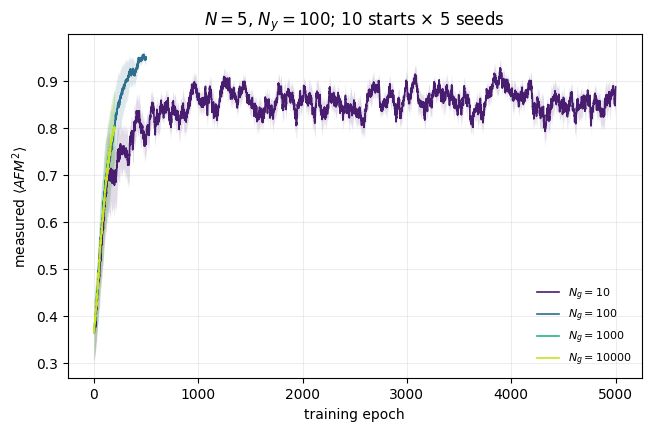

In [80]:
summary_path = DATA_DIR / f"trajectory_overlap_summary_N{N}.npz"
with load(summary_path) as d:
    info = json.loads(str(d["metadata"]))
    assert info["complete"] and info["N"] == N and info["N_y"] == N_Y
    assert info["initial_points"] == 10 and info["seeds_per_point"] == 5
    np.testing.assert_array_equal(d["N_g"], TRAJECTORY_NG)
    fig, ax = plt.subplots(figsize=(6.4, 4.2), layout="constrained")
    for N_g in TRAJECTORY_NG:
        epoch = d[f"epoch_Ng{N_g}"]
        x = epoch
        mean, sem = d[f"mean_Ng{N_g}"], d[f"sem_Ng{N_g}"]
        color = COLORS[NG_GRID.index(N_g)]
        ax.plot(x, mean, color=color, lw=1.2, label=rf"$N_g={N_g}$")
        ax.fill_between(x, mean-sem, mean+sem, color=color, alpha=0.16, linewidth=0)
finish(ax, "training epoch",
       r"measured $\langle AFM^2\rangle$",
       rf"$N={N}$, $N_y={N_Y}$; 10 starts $\times$ 5 seeds")
print("50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).")
print("Epoch counts for Ng=10/100/1000/10000: 5000/500/200/200; no smoothing.")
save_show(fig, f"performance_vs_epoch_N{N}")


## 10. Performance versus cumulative gradient shots

All curves use **10 initial parameter sets × 5 sampling seeds per set** (50 paths per $N_g$).
The trained parameters are $\Omega,\Delta$, with $V=1$ fixed.
Training lengths are 5,000 / 500 / 200 / 200 epochs for $N_g=10/100/1000/10000$;
$N_y=100$, $\beta=0.1$, and learning rate $0.01$.
Means give equal weight to each start and seed. Shading is **±1 SEM across the 10
initial-point means**, each averaging five seeds; it is not a 95% interval.
These starts are the selected ensemble, not a guarantee about all initial conditions.
No smoothing or new measurement sampling is applied.
The historical 100-step approximate training-state solver is retained.

The horizontal axis now counts **physical gradient preparations, $4N_g$ per epoch**:
two noncommuting measurement bases in each of the free and nudged states.
This corrects the older $2N_g$ paired-preparation label; $N_y$ output shots are excluded.
The displayed pre-update measurement at epoch $k+1$ is placed at its allocated
cost $4N_g(k+1)$, including that epoch's gradient allocation.
All four curves share the physical-shot range **40,000–200,000**.
The expanded summary is mandatory; there is no fallback to the old 3-start ensemble.
Figure 11's separate trajectory-observable panel is unchanged by this update.


50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).
Epoch counts for Ng=10/100/1000/10000: 5000/500/200/200; no smoothing.
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_gradient_shots_N5.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_gradient_shots_N5.png


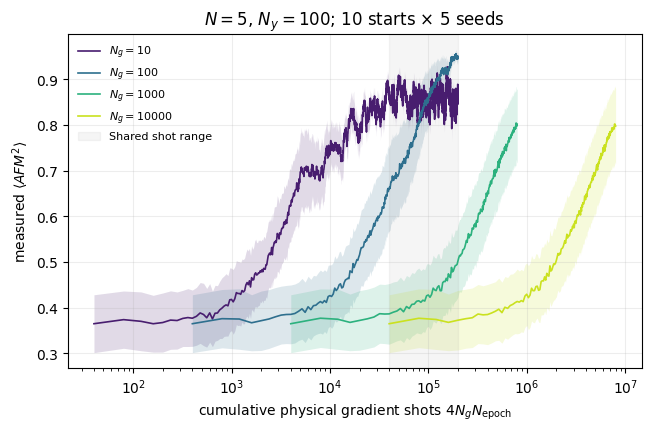

In [81]:
summary_path = DATA_DIR / f"trajectory_overlap_summary_N{N}.npz"
with load(summary_path) as d:
    info = json.loads(str(d["metadata"]))
    assert info["complete"] and info["N"] == N and info["N_y"] == N_Y
    assert info["initial_points"] == 10 and info["seeds_per_point"] == 5
    np.testing.assert_array_equal(d["N_g"], TRAJECTORY_NG)
    fig, ax = plt.subplots(figsize=(6.4, 4.2), layout="constrained")
    for N_g in TRAJECTORY_NG:
        epoch = d[f"epoch_Ng{N_g}"]
        x = 4 * N_g * epoch
        mean, sem = d[f"mean_Ng{N_g}"], d[f"sem_Ng{N_g}"]
        color = COLORS[NG_GRID.index(N_g)]
        ax.plot(x, mean, color=color, lw=1.2, label=rf"$N_g={N_g}$")
        ax.fill_between(x, mean-sem, mean+sem, color=color, alpha=0.16, linewidth=0)
    ax.axvspan(40_000, info["common_physical_gradient_budget"], color="0.5",
               alpha=0.08, label="Shared shot range")
    ax.set_xscale("log")
finish(ax, r"cumulative physical gradient shots $4N_gN_{\rm epoch}$",
       r"measured $\langle AFM^2\rangle$",
       rf"$N={N}$, $N_y={N_Y}$; 10 starts $\times$ 5 seeds")
print("50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).")
print("Epoch counts for Ng=10/100/1000/10000: 5000/500/200/200; no smoothing.")
save_show(fig, f"performance_vs_gradient_shots_N{N}")


## 11. Measured and exact $\langle AFM^2\rangle$ during training

For each $N_g$, average over **all 3 initial parameter points and 5 seeds** (15 runs).
Dashed curves use the saved measurements, with **$N_y=100$ output shots per run per epoch**;
solid curves use the exact free ground-state expectation at each run's actual parameters.
$N_g$ controls gradient shots, not output shots. This is $\langle AFM^2\rangle$, not
$\langle AFM\rangle^2$.

The 200 plotted epochs are **pre-update**: epoch 1 uses the initial parameters;
epoch 200 uses parameters after 199 updates. Both curves use the same parameter points.
Exact expectations were precomputed outside this notebook in
`shot_study/trajectory_expectations.py`; this cell only loads and plots saved data.


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_measured_vs_exact_N5.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_measured_vs_exact_N5.png


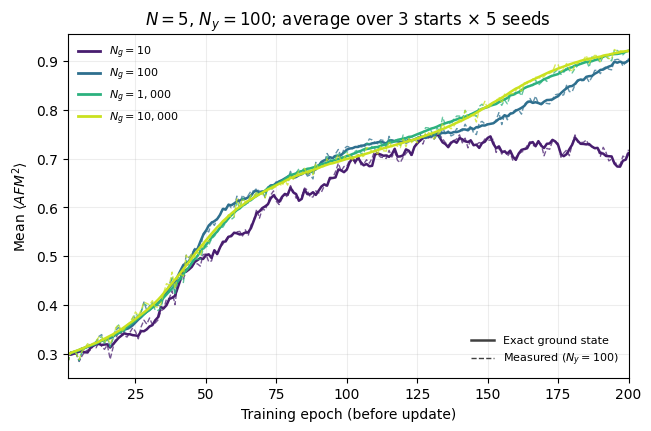

In [82]:
from matplotlib.lines import Line2D

with load(DATA_DIR / f"trajectory_expectations_N{N}.npz") as d:
    metadata = json.loads(str(d["metadata"]))
    assert metadata["N"] == N and metadata["N_y"] == N_Y
    epoch = d["epoch"]
    ng_values = d["N_g"]
    # Axes: N_g, run (3 initial points x 5 seeds), epoch.
    measured_mean = d["measured_AM2"].mean(axis=1)
    exact_mean = d["exact_AM2"].mean(axis=1)

fig, ax = plt.subplots(figsize=(6.4, 4.2), layout="constrained")
ng_handles = []
for i, N_g in enumerate(ng_values):
    color = COLORS[NG_GRID.index(int(N_g))]
    ax.plot(epoch, measured_mean[i], color=color, ls="--", lw=1.0, alpha=0.75)
    ax.plot(epoch, exact_mean[i], color=color, ls="-", lw=1.8)
    ng_handles.append(Line2D([], [], color=color, lw=2, label=rf"$N_g={N_g:,}$"))

finish(
    ax, "Training epoch (before update)", r"Mean $\langle AFM^2\rangle$",
    rf"$N={N}$, $N_y={N_Y}$; average over 3 starts $\times$ 5 seeds",
    legend=False,
)
ax.set_xlim(epoch[0], epoch[-1])
ng_legend = ax.legend(handles=ng_handles, loc="upper left", frameon=False, fontsize=8)
ax.add_artist(ng_legend)
ax.legend(handles=[
    Line2D([], [], color="0.25", ls="-", lw=1.8, label="Exact ground state"),
    Line2D([], [], color="0.25", ls="--", lw=1, label=rf"Measured ($N_y={N_Y}$)"),
], loc="lower right", frameon=False, fontsize=8)
save_show(fig, f"performance_measured_vs_exact_N{N}")


## 11b. Fixed-shot-budget curves: 10 starts × 5 seeds

All curves use **10 initial parameter sets × 5 sampling seeds per set** (50 paths per $N_g$).
The trained parameters are $\Omega,\Delta$, with $V=1$ fixed.
Training lengths are 5,000 / 500 / 200 / 200 epochs for $N_g=10/100/1000/10000$;
$N_y=100$, $\beta=0.1$, and learning rate $0.01$.
Means give equal weight to each start and seed. Shading is **±1 SEM across the 10
initial-point means**, each averaging five seeds; it is not a 95% interval.
These starts are the selected ensemble, not a guarantee about all initial conditions.
No smoothing or new measurement sampling is applied.
The historical 100-step approximate training-state solver is retained.

This plot now uses the **same expanded ensemble as Figures 9 and 10**, at
$N_g=10,100,1000,10000$ only. Intermediate $N_g$ values have not been simulated
for these 10 starts and are not interpolated or borrowed from the single-start study.

For physical gradient-shot caps $S=10,000,20,000,40,000,100,000,200,000$, take
$k=\lfloor S/(4N_g)\rfloor$ completed updates and evaluate **exact ground-state
$\langle AFM^2\rangle$ at $(\Omega_k,\Delta_k)$** using float64 diagonalization.
These are the same epoch checkpoints as the former paired budgets $B=S/2$.
Cases with $k=0$ are omitted; no endpoint beyond a completed trajectory is used.
Rounding can leave unused shots. Output shots ($100k$) are not included in $S$.
Exact endpoint evaluation does not correct the approximate training-state solver.

Endpoint calculations and validation live in `shot_study/summarize_overlap.py`,
outside this plotting-only notebook. The new versioned export is
[10-start / 5-seed PDF](figures/shots_2026-09-11/time_budget_N5_10starts_5seeds.pdf).
The previous [single-start / 25-seed PDF](figures/shots_2026-09-11/time_budget_N5_25seeds.pdf)
and its data are preserved as a separate fluctuation-check experiment. Its dip
conclusions must not be transferred to this different initial-condition ensemble.


50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).
S is the physical gradient-shot cap; epochs=floor(S/(4*Ng)); Ny shots excluded.
Only Ng=10,100,1000,10000 were run for this expanded ensemble.
Training retains the historical 100-step solver; endpoints use exact diagonalization.
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/time_budget_N5.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/time_budget_N5.png


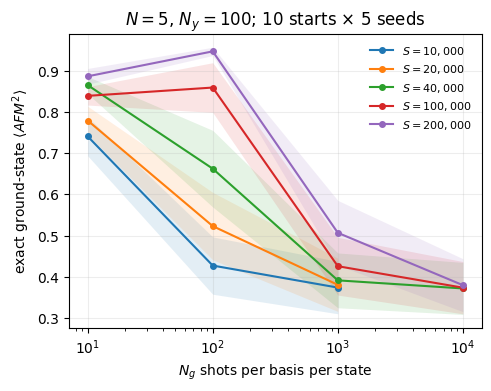

In [83]:
summary_path = DATA_DIR / f"trajectory_overlap_summary_N{N}.npz"
with load(summary_path) as d:
    info = json.loads(str(d["metadata"]))
    assert info["complete"] and info["N"] == N and info["N_y"] == N_Y
    assert info["initial_points"] == 10 and info["seeds_per_point"] == 5
    np.testing.assert_array_equal(d["N_g"], TRAJECTORY_NG)
    budgets = d["physical_budgets"]
    budget_matrix, budget_sem = d["budget_mean"].T, d["budget_sem"].T

fig, ax = plt.subplots(figsize=(4.8, 3.8), layout="constrained")
for i, budget in enumerate(budgets):
    valid = np.isfinite(budget_matrix[i])
    x = np.asarray(TRAJECTORY_NG)[valid]
    mean, sem = budget_matrix[i, valid], budget_sem[i, valid]
    line, = ax.plot(x, mean, "o-", lw=1.5, ms=4, label=rf"$S={budget:,}$")
    ax.fill_between(x, mean-sem, mean+sem, color=line.get_color(),
                    alpha=0.12, linewidth=0)
ax.set_xscale("log")
finish(ax, r"$N_g$ shots per basis per state",
       r"exact ground-state $\langle AFM^2\rangle$",
       rf"$N={N}$, $N_y={N_Y}$; 10 starts $\times$ 5 seeds")
print("50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).")
print("S is the physical gradient-shot cap; epochs=floor(S/(4*Ng)); Ny shots excluded.")
print("Only Ng=10,100,1000,10000 were run for this expanded ensemble.")
print("Training retains the historical 100-step solver; endpoints use exact diagonalization.")
for suffix in (".pdf", ".png"):
    kwargs = {"dpi": 180} if suffix == ".png" else {}
    fig.savefig(FIG_DIR / f"time_budget_N{N}_10starts_5seeds{suffix}",
                bbox_inches="tight", **kwargs)
save_show(fig, f"time_budget_N{N}")


## 11c. Fixed-shot budget from the green trajectory start (25 seeds)

**The three green-start figures have separate editable plotting cells below.**
Run the notebook's setup/import cell first, then run the desired figure cell:

- **11c:** time budget — `time_budget_N5_green_init1_25seeds.pdf`.
- **11d:** measured versus exact — `performance_measured_vs_exact_N5_green_init1_25seeds.pdf`.
- **11e:** performance versus epochs — `performance_vs_epochs_N5_green_init1_25seeds.pdf`.

Each cell contains its plotting code directly (not a call to a training script),
loads already-computed data, and saves both PDF and PNG. Edit sizes, colors,
line widths, or selected `N_g` values in the corresponding cell.

The green start in the `*_cell62` trajectory plots is
$(\Omega_0,\Delta_0)=(0.6954632245521951,1.9556663479392087)$ (initial-set ID 1).
Plot coordinates are $(x,y)=(\Delta,\Omega)$.
It is **not** the old 25-seed experiment's $(0.5,1.5)$ start.

This new experiment uses 25 seeds at each of all ten $N_g$ values, with
$N_y=100$, $\beta=0.1$, learning rate $0.01$, fixed $V=1$, and the same historical
100-step approximate training-state solver. All runs are freshly generated;
seed bases 1000–1024 follow the init-ID-1 convention, but numerical-backend
differences mean the first five are not asserted to reproduce old paths bitwise.

Physical caps $S=10,000,20,000,40,000,100,000,200,000$ correspond to old
paired caps $B=S/2$. Endpoints use $k=\lfloor S/(4N_g)\rfloor$ updates and
exact ground-state $\langle AFM^2\rangle$; $k=0$ cases are omitted.
Output shots $100k$ are excluded. Bands show pointwise 95% seed-bootstrap
intervals (20,000 resamples), matching the old 25-seed figure's uncertainty convention.

Training, validation, and bootstrap aggregation run outside this notebook via
`shot_study/green_start_budget.py`. This cell only loads the completed summary.
If the summary has not yet been downloaded, it stops explicitly rather than
showing unrelated data. Saves `time_budget_N5_green_init1_25seeds.pdf/png`;
neither previous time-budget figure is overwritten.


25 seeds at the green start; pointwise 95% bootstrap intervals.
Physical gradient-shot cap S=2B; Ny output shots excluded.
Historical 100-step training solver retained; exact endpoints.
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/time_budget_N5_green_init1_25seeds.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/time_budget_N5_green_init1_25seeds.png


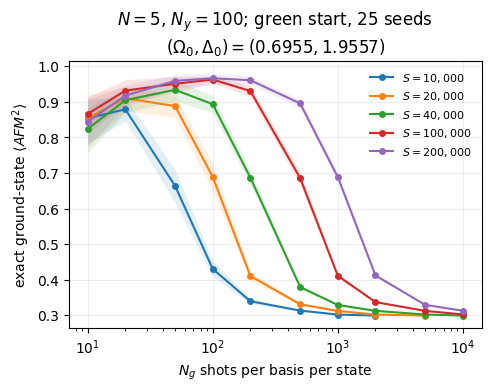

In [84]:
green_summary = DATA_DIR / "time_budget_green_init1_N5_25seeds.npz"
if not green_summary.exists():
    raise FileNotFoundError(
        "Green-start 25-seed results are not available locally yet. "
        "Wait for training/aggregation, then download the completed summary."
    )
with load(green_summary) as d:
    info = json.loads(str(d["metadata"]))
    assert N == 5 and info["N"] == 5 and info["N_y"] == N_Y
    assert info["complete"] and info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [0.6954632245521951, 1.9556663479392087])
    np.testing.assert_array_equal(d["N_g"], NG_GRID)
    ng_values, caps = d["N_g"], d["physical_budgets"]
    means, lo, hi = d["mean"], d["ci95_low"], d["ci95_high"]
fig, ax = plt.subplots(figsize=(4.8, 3.8), layout="constrained")
for b, cap in enumerate(caps):
    valid = np.isfinite(means[:, b])
    x = ng_values[valid]
    line, = ax.plot(x, means[valid, b], "o-", lw=1.5, ms=4, label=rf"$S={cap:,}$")
    ax.fill_between(x, lo[valid, b], hi[valid, b],
                    color=line.get_color(), alpha=0.12, linewidth=0)
ax.set_xscale("log")
finish(ax, r"$N_g$ shots per basis per state",
       r"exact ground-state $\langle AFM^2\rangle$",
       r"$N=5$, $N_y=100$; green start, 25 seeds" + "\n" +
       r"$(\Omega_0,\Delta_0)=(0.6955,1.9557)$")
print("25 seeds at the green start; pointwise 95% bootstrap intervals.")
print("Physical gradient-shot cap S=2B; Ny output shots excluded.")
print("Historical 100-step training solver retained; exact endpoints.")
save_show(fig, "time_budget_N5_green_init1_25seeds")


## 11d. Green-start training curves: measured and exact expectations

Uses the same **one green initial point × 25 sampling seeds** as Figure 11c,
at all ten $N_g$ values. $N_y=100$ is the number of output measurements per
epoch; $N_g$ is the gradient shots per basis per state. The observable is
$\langle AFM^2\rangle$, not $\langle AFM\rangle^2$.

Training lengths are 5000, 2500, 1000, 500, 250, 100, 50, 25, 10, 5 epochs for
$N_g=10,20,50,100,200,500,1000,2000,5000,10000$, respectively.
No trajectories are extended or padded. The logarithmic epoch axis displays
these different lengths without hiding the short runs; change `xscale` to
`"linear"` in either plotting cell if preferred.

At plotted epoch $k+1$, both curves refer to $(\Omega_k,\Delta_k)$ **before**
the update: dashed curves are the saved $N_y=100$ measurements; solid curves
are float64 exact ground-state expectations at those same parameters.
Thus the final plotted pre-update point differs by one update from the
post-update endpoint in the time-budget figure.
Training still uses the historical 100-step approximate state solver.
A measured–exact discrepancy can therefore contain preparation bias as well
as sampling fluctuation; it must not automatically be called measurement noise.

Means and pointwise **±1 SEM across 25 seeds** are unsmoothed. Bands are not
95% intervals (unlike the separate time-budget bootstrap plot).
Exact expectations were cached outside this notebook using
`shot_study/green_trajectory_expectations.py`; these cells only load and plot.
The old ensemble plots are preserved under their original filenames.


All available pre-update points; 25 seeds per Ng; no smoothing or new sampling.
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_measured_vs_exact_N5_green_init1_25seeds.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_measured_vs_exact_N5_green_init1_25seeds.png


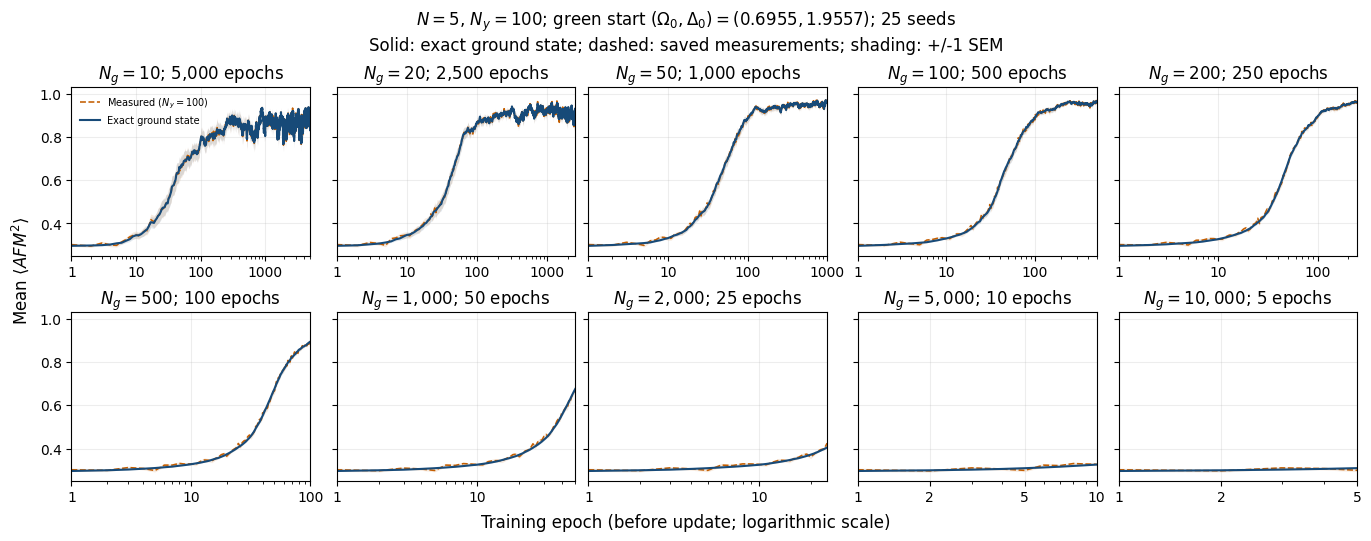

In [85]:
green_expectations = DATA_DIR / "green_trajectory_expectations_N5_25seeds.npz"
with load(green_expectations) as d:
    info = json.loads(str(d["metadata"]))
    assert N == 5 and info["N"] == 5 and info["N_y"] == N_Y
    assert info["complete"] and info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [0.6954632245521951, 1.9556663479392087])
    from matplotlib.ticker import FuncFormatter, NullFormatter
    selected_ng = tuple(int(ng) for ng in d["N_g"])  # Edit to choose which panels to show.
    ncols = 5
    nrows = int(np.ceil(len(selected_ng) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13.6, 2.65*nrows),
                             sharey=True, squeeze=False, layout="constrained")
    for ax, ng in zip(axes.flat, selected_ng):
        epoch = d[f"epoch_Ng{ng}"]
        for name, color, style, label in (
            ("measured", "#C45E00", "--", rf"Measured ($N_y={N_Y}$)"),
            ("exact", "#174A78", "-", "Exact ground state"),
        ):
            mean = d[f"{name}_mean_Ng{ng}"]
            sem = d[f"{name}_sem_Ng{ng}"]
            ax.plot(epoch, mean, color=color, ls=style,
                    lw=1.15 if name == "measured" else 1.5, label=label)
            ax.fill_between(epoch, mean-sem, mean+sem, color=color, alpha=0.12, linewidth=0)
        ax.set(xscale="log", xlim=(1, int(epoch[-1])), ylim=(0.25, 1.03),
               title=rf"$N_g={ng:,}$; {len(epoch):,} epochs")
        ticks = ([1, 2, 5, 10] if epoch[-1] <= 10 else [1, 10, 100, 1000, 10000])
        ax.set_xticks([tick for tick in ticks if tick <= epoch[-1]])
        ax.xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"{value:g}"))
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.grid(alpha=0.22)
    for ax in list(axes.flat)[len(selected_ng):]:
        ax.set_visible(False)
    axes[0, 0].legend(frameon=False, fontsize=7, loc="upper left")
fig.supxlabel("Training epoch (before update; logarithmic scale)")
fig.supylabel(r"Mean $\langle AFM^2\rangle$")
fig.suptitle(r"$N=5$, $N_y=100$; green start $(\Omega_0,\Delta_0)=(0.6955,1.9557)$; 25 seeds"
             + "\nSolid: exact ground state; dashed: saved measurements; shading: +/-1 SEM")
print("All available pre-update points; 25 seeds per Ng; no smoothing or new sampling.")
save_show(fig, "performance_measured_vs_exact_N5_green_init1_25seeds")


## 11e. Green-start performance versus epochs (25 seeds)

The following cell plots the saved measured averages for all ten `N_g` values.
Edit `selected_ng`, `figsize`, `palette`, `lw`, or the axis scale here.
It saves `performance_vs_epochs_N5_green_init1_25seeds.pdf/png`.
The data, epoch alignment, and SEM convention are described in section 11d;
this cell needs only the notebook setup and the precomputed data files.


All ten Ng values; each curve stops at its actual training length.
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_epochs_N5_green_init1_25seeds.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_epochs_N5_green_init1_25seeds.png


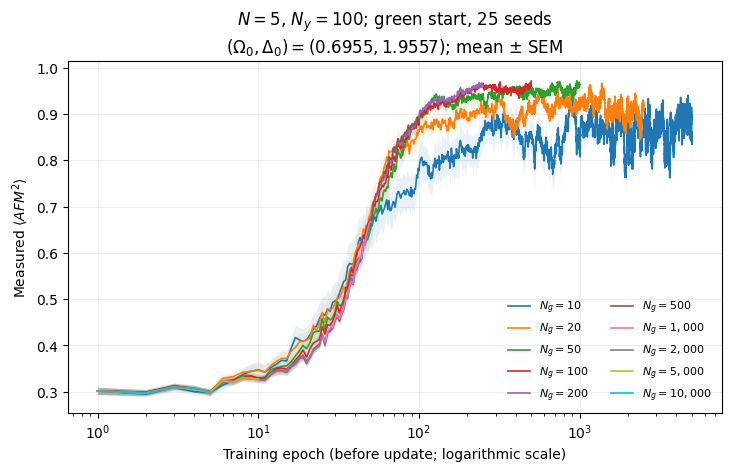

In [86]:
green_expectations = DATA_DIR / "green_trajectory_expectations_N5_25seeds.npz"
with load(green_expectations) as d:
    info = json.loads(str(d["metadata"]))
    assert N == 5 and info["N"] == 5 and info["N_y"] == N_Y
    assert info["complete"] and info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [0.6954632245521951, 1.9556663479392087])
    selected_ng = tuple(int(ng) for ng in d["N_g"])  # Edit this tuple to select curves.
    fig, ax = plt.subplots(figsize=(7.2, 4.6), layout="constrained")
    palette = plt.get_cmap("tab10")
    for i, ng in enumerate(selected_ng):
        epoch = d[f"epoch_Ng{ng}"]
        mean, sem = d[f"measured_mean_Ng{ng}"], d[f"measured_sem_Ng{ng}"]
        color = palette(i % 10)
        ax.plot(epoch, mean, color=color, lw=1.2, label=rf"$N_g={ng:,}$")
        ax.fill_between(epoch, mean-sem, mean+sem, color=color, alpha=0.10, linewidth=0)
ax.set_xscale("log")  # Use "linear" if preferred.
finish(ax, "Training epoch (before update; logarithmic scale)",
       r"Measured $\langle AFM^2\rangle$",
       r"$N=5$, $N_y=100$; green start, 25 seeds" + "\n" +
       r"$(\Omega_0,\Delta_0)=(0.6955,1.9557)$; mean $\pm$ SEM", legend=False)
ax.legend(ncol=2, frameon=False, fontsize=8, loc="lower right")
print("All ten Ng values; each curve stops at its actual training length.")
save_show(fig, "performance_vs_epochs_N5_green_init1_25seeds")


## 12. Fixed-shot-budget heatmap


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/time_budget_heat_N5.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/time_budget_heat_N5.png


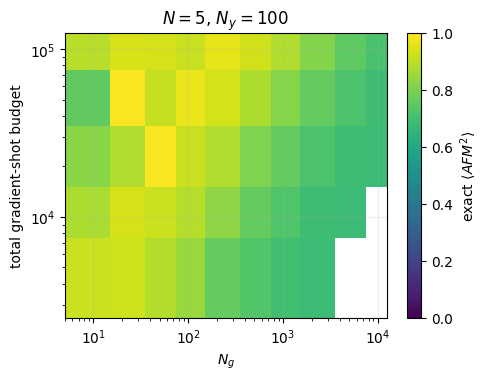

In [87]:
budget_matrix = load_budget_matrix()

fig, ax = plt.subplots(figsize=(5.2, 3.7))
masked = np.ma.masked_invalid(budget_matrix)
mesh = ax.pcolormesh(
    np.asarray(NG_GRID),
    np.asarray(SHOT_BUDGETS),
    masked,
    shading="nearest",
    cmap="viridis",
    vmin=0,
    vmax=1,
)
ax.set_xscale("log")
ax.set_yscale("log")
fig.colorbar(
    mesh, ax=ax, label=r"exact $\langle AFM^2\rangle$"
)
finish(
    ax,
    r"$N_g$",
    "total gradient-shot budget",
    rf"$N={N}$, $N_y={N_Y}$",
    legend=False,
)
save_show(fig, f"time_budget_heat_N{N}")


## 13. Gradient moments during training


### Physical mechanism: why can the two relative-noise curves nearly overlap?

**Similar relative noise does not mean shared measurement outcomes.** Here the plotted quantity is
$R_i=\sigma(g_i)/|\mu_i|$, with $\mu_i=\mathbb{E}[g_i\mid\Omega,\Delta,y]$.
The two components can have very different absolute noise and signal, but similar ratios.

#### 1. Small transverse-field admixtures around the ordered AFM state

Write
$$
H_f=H_Z+\Omega A_\Omega,\qquad
A_\Omega=\frac12\sum_jX_j,\qquad A_\Delta=-\sum_j n_j.
$$

Inside the gapped AFM region, assume the classical $\Omega=0$ ground state $|a\rangle$
is a nondegenerate alternating $Z$-basis product state. Let $|j\rangle$ be the state
with spin $j$ flipped, with excitation gap $\epsilon_j>0$.
First-order nondegenerate perturbation theory gives
$$
|\psi_f\rangle=|a\rangle-\frac{\Omega}{2}
\sum_j\frac{|j\rangle}{\epsilon_j}+O(\Omega^2).
$$
Thus spin-flip **amplitudes** are proportional to $\Omega$, whereas their
**probabilities** are proportional to $\Omega^2$.
The expansion is the standard one described in
[MIT's perturbation-theory notes, Sec. 1.1](https://www.ocw.mit.edu/courses/8-06-quantum-physics-iii-spring-2018/a0889c5ca8a479c3e56c544d646fb770_MIT8_06S18ch1.pdf);
the consequences below are for our AFM Hamiltonian.

$A_\Omega$ connects $|a\rangle$ to the single-spin-flip states, so its expectation
changes at order $\Omega$. Even at $\Omega=0$, an $X$ measurement on a $Z$-basis
state is uncertain:
$$
\operatorname{Var}(A_\Omega)=\frac{N}{4}+O(\Omega^2).
$$
By contrast, $|a\rangle$ is an eigenstate of the diagonal operator $A_\Delta$.
Its expectation changes only through the small defect probabilities, and
$$
\langle A_\Delta\rangle-\langle a|A_\Delta|a\rangle=O(\Omega^2),
\qquad
\operatorname{Var}(A_\Delta)=O(\Omega^2).
$$

#### 2. The QEP signal and noise lose the same extra power of Omega

For the squared loss and $C=\mathrm{AFM}^2$, the nudged Hamiltonian is
$$
H_n=H_f+\kappa C,\qquad \kappa=2\beta(y-1).
$$
Because $C$ is diagonal, this nudge changes the defect gaps without directly
creating spin flips. For weak nudging, away from gap closings and cancellations
of the leading response, the difference of expectations therefore scales as
$\kappa\Omega$ for $A_\Omega$ and $\kappa\Omega^2$ for $A_\Delta$.

With **independent** $N_g$-shot measurements of each component in each state,
$$
\mu_i=\frac{\langle A_i\rangle_n-\langle A_i\rangle_f}{\beta},
\qquad
\sigma_i^2=
\frac{\operatorname{Var}_n(A_i)+\operatorname{Var}_f(A_i)}
     {N_g\beta^2}.
$$

At fixed $\Delta$, with nonzero leading coefficients:

| Component | Magnitude of mean gradient | Gradient standard deviation | Relative noise |
|---|---|---|---|
| $\Omega$ | $\propto |1-y|\,|\Omega|$ | $\propto 1/(|\beta|\sqrt{N_g})$ | $\propto 1/(|\beta|\sqrt{N_g}|1-y|\,|\Omega|)$ |
| $\Delta$ | $\propto |1-y|\,\Omega^2$ | $\propto |\Omega|/(|\beta|\sqrt{N_g})$ | $\propto 1/(|\beta|\sqrt{N_g}|1-y|\,|\Omega|)$ |

**The Delta noise vanishes, but its signal vanishes one power of Omega faster.
The Omega noise stays finite, while its signal also vanishes.
Both relative noises can consequently diverge with the same leading scaling.**

Their prefactors depend on the excitation gaps and response matrix elements;
there is no principle requiring equality. Along training, the additional shared
factor $1/|1-y|$ also makes both curves rise and spike together. At $y=1$ their
conditional mean gradients vanish, so a finite relative-noise ratio is generally
not defined. If the exact output satisfies $1-y=O(\Omega^2)$, the combined
leading scaling is instead $R_i\propto|\Omega|^{-3}$ for both components;
the table retains the actual, separately sampled $y$ explicitly.

#### 3. Independent numerical check of this mechanism

A separate float64 ground-state diagonalization check (not the 100-step solver)
at $N=5$, $\Delta=1.4$, fixed $y=0.9$, $\beta=0.1$, $N_g=1000$ found
the following log-log slopes over $\Omega=0.1,0.05,0.025$:

$$
\bigl(
d\log|\mu_\Omega|/d\log|\Omega|,
d\log|\mu_\Delta|/d\log|\Omega|,
d\log\sigma_\Omega/d\log|\Omega|,
d\log\sigma_\Delta/d\log|\Omega|
\bigr)
=(1.000,\ 1.983,\ -0.002,\ 0.996),
$$

consistent with the predicted $(1,2,0,1)$.
The exact relative noises at $\Omega=0.05$ were $(22.45,23.47)$, and at
$\Omega=0.025$ they were $(44.92,46.76)$: nearly the same scaling without shared shots.
This controlled check is reproducible through
`shot_study.audit_component_noise.check_afm_scaling()`;
it is not a refit or replacement of the saved training data.

**Scope and caveats.** This is a small-$|\Omega|$, gapped-AFM explanation,
not a universal identity for noncommuting observables or all training points.
Figure 13 shows noise conditional on its sampled $y$, not total output-plus-gradient
noise. The seed audit found independent component streams, but the existing
training data still use the separately identified 100-step approximate state solver;
the physical mechanism does not remove that numerical-accuracy issue.


Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_moments_during_training_N5.pdf
Saved as /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/gradient_moments_during_training_N5.png


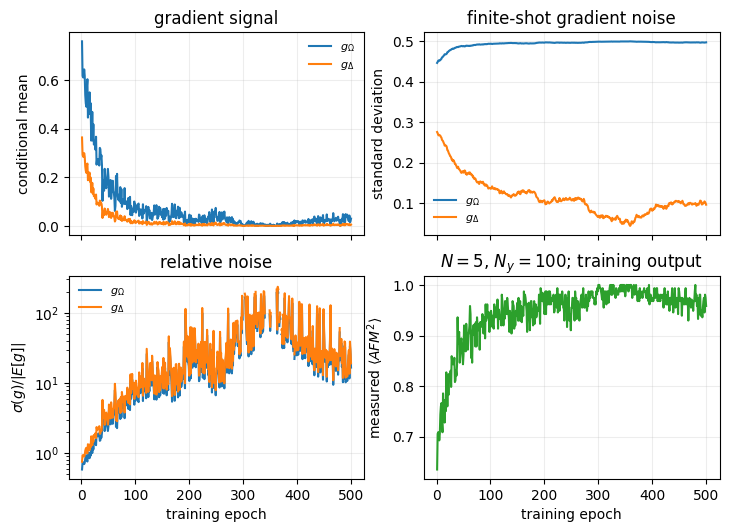

In [88]:
d = load(
    DATA_DIR / f"gradient_during_training_N{N}.npz"
)
mean = d["expected_gradient"]
std = np.sqrt(np.maximum(d["gradient_variance"], 0))
ratio = np.divide(
    std,
    np.abs(mean),
    out=np.full_like(std, np.nan),
    where=np.abs(mean) > 1e-12,
)
epoch = np.arange(1, len(mean) + 1)

fig, axes = plt.subplots(
    2, 2, figsize=(8.4, 5.8), sharex=True
)
for p, label in enumerate(PARAM_LABELS):
    axes[0, 0].plot(epoch, mean[:, p], label=label)
    axes[0, 1].plot(epoch, std[:, p], label=label)
    axes[1, 0].semilogy(epoch, ratio[:, p], label=label)
axes[1, 1].plot(epoch, d["measured_AM2"], color="C2")
finish(
    axes[0, 0], "", "conditional mean", "gradient signal"
)
finish(
    axes[0, 1],
    "",
    "standard deviation",
    "finite-shot gradient noise",
)
finish(
    axes[1, 0],
    "training epoch",
    r"$\sigma(g)/|E[g]|$",
    "relative noise",
)
finish(
    axes[1, 1],
    "training epoch",
    r"measured $\langle AFM^2\rangle$",
    rf"$N={N}$, $N_y={N_Y}$; training output",
    legend=False,
)
save_show(fig, f"gradient_moments_during_training_N{N}")


# NEW: Three green-start figures — 25 seeds

**The figure-generating code is in the three cells immediately below the setup cell.**
Run this bottom setup once, then run any of the three plotting cells independently.
No earlier notebook cells are needed. All data are already computed; these cells
only load and plot them, with no training or diagonalization.

1. `time_budget_N5_green_init1_25seeds.pdf`
2. `performance_measured_vs_exact_N5_green_init1_25seeds.pdf`
3. `performance_vs_epochs_N5_green_init1_25seeds.pdf`

Each also saves a PNG. Edit figure sizes, colors, line widths, or axis settings
directly in its cell. The fixed green start is
$(\Omega_0,\Delta_0)=(0.6954632246,1.9556663479)$, with $N_y=100$.
Time-budget shading is a pointwise 95% bootstrap interval; epoch-curve shading
is ±1 SEM across the 25 seeds.


In [89]:
# Run this setup once; the three following cells generate the three green-start PDFs.
# This bottom section is independent of all earlier notebook cells.
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

_candidates = [
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "AFM_searching",
                      parent / "QEP_multiple_shot" / "AFM_searching")
]
STUDY_DIR = next(
    candidate.resolve() for candidate in _candidates
    if (candidate / "data" / "shots_2026-09-11" /
        "time_budget_green_init1_N5_25seeds.npz").is_file()
)
DATA_DIR = STUDY_DIR / "data" / "shots_2026-09-11"
FIG_DIR = STUDY_DIR / "figures" / "shots_2026-09-11"
FIG_DIR.mkdir(parents=True, exist_ok=True)
N, N_Y = 5, 100
NG_GRID = (10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000)

def load(path):
    return np.load(path, allow_pickle=False)

def finish(ax, xlabel, ylabel, title=None, legend=True):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(alpha=0.22)
    if legend:
        ax.legend(frameon=False, fontsize=8)

def save_show(fig, stem):
    for suffix in (".pdf", ".png"):
        options = {"dpi": 180} if suffix == ".png" else {}
        path = FIG_DIR / f"{stem}{suffix}"
        fig.savefig(path, bbox_inches="tight", **options)
        print("Saved:", path)
    plt.show()

print("Green-start data:", DATA_DIR)
print("Figure output:", FIG_DIR)


Green-start data: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/data/shots_2026-09-11
Figure output: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11


25 seeds at the green start; pointwise 95% bootstrap intervals.
Physical gradient-shot cap S=2B; Ny output shots excluded.
Historical 100-step training solver retained; exact endpoints.
Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/time_budget_N5_green_init1_25seeds.pdf
Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/time_budget_N5_green_init1_25seeds.png


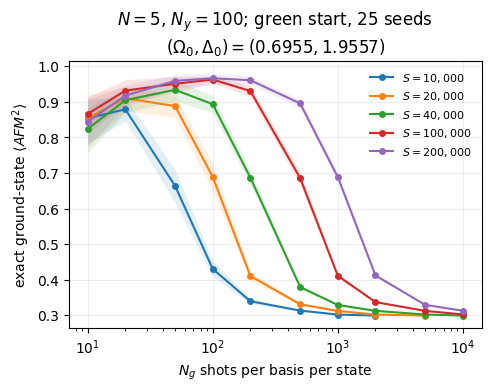

In [90]:
# GENERATES: time_budget_N5_green_init1_25seeds.pdf
# Edit this cell directly; run the bottom setup cell first.
green_summary = DATA_DIR / "time_budget_green_init1_N5_25seeds.npz"
if not green_summary.exists():
    raise FileNotFoundError(
        "Green-start 25-seed results are not available locally yet. "
        "Wait for training/aggregation, then download the completed summary."
    )
with load(green_summary) as d:
    info = json.loads(str(d["metadata"]))
    assert N == 5 and info["N"] == 5 and info["N_y"] == N_Y
    assert info["complete"] and info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [0.6954632245521951, 1.9556663479392087])
    np.testing.assert_array_equal(d["N_g"], NG_GRID)
    ng_values, caps = d["N_g"], d["physical_budgets"]
    means, lo, hi = d["mean"], d["ci95_low"], d["ci95_high"]
fig, ax = plt.subplots(figsize=(4.8, 3.8), layout="constrained")
for b, cap in enumerate(caps):
    valid = np.isfinite(means[:, b])
    x = ng_values[valid]
    line, = ax.plot(x, means[valid, b], "o-", lw=1.5, ms=4, label=rf"$S={cap:,}$")
    ax.fill_between(x, lo[valid, b], hi[valid, b],
                    color=line.get_color(), alpha=0.12, linewidth=0)
ax.set_xscale("log")
finish(ax, r"$N_g$ shots per basis per state",
       r"exact ground-state $\langle AFM^2\rangle$",
       r"$N=5$, $N_y=100$; green start, 25 seeds" + "\n" +
       r"$(\Omega_0,\Delta_0)=(0.6955,1.9557)$")
print("25 seeds at the green start; pointwise 95% bootstrap intervals.")
print("Physical gradient-shot cap S=2B; Ny output shots excluded.")
print("Historical 100-step training solver retained; exact endpoints.")
save_show(fig, "time_budget_N5_green_init1_25seeds")


All ten Ng values; each curve stops at its actual training length.
Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_epochs_N5_green_init1_25seeds.pdf
Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_epochs_N5_green_init1_25seeds.png


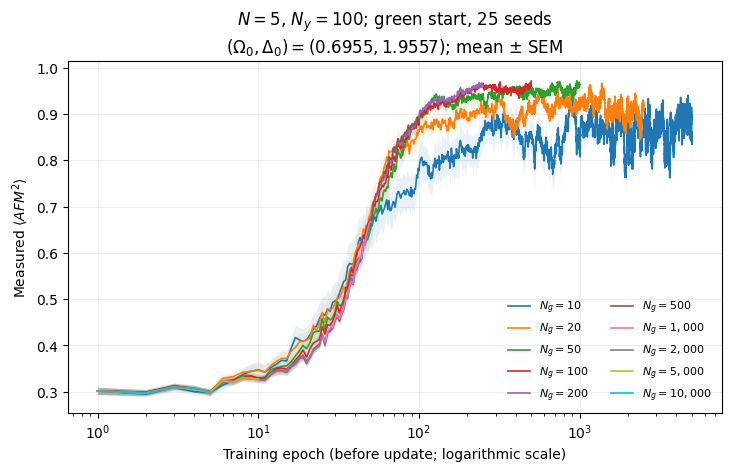

In [92]:
# GENERATES: performance_vs_epochs_N5_green_init1_25seeds.pdf
# Edit this cell directly; run the bottom setup cell first.
green_expectations = DATA_DIR / "green_trajectory_expectations_N5_25seeds.npz"
with load(green_expectations) as d:
    info = json.loads(str(d["metadata"]))
    assert N == 5 and info["N"] == 5 and info["N_y"] == N_Y
    assert info["complete"] and info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [0.6954632245521951, 1.9556663479392087])
    selected_ng = tuple(int(ng) for ng in d["N_g"])  # Edit this tuple to select curves.
    fig, ax = plt.subplots(figsize=(7.2, 4.6), layout="constrained")
    palette = plt.get_cmap("tab10")
    for i, ng in enumerate(selected_ng):
        epoch = d[f"epoch_Ng{ng}"]
        mean, sem = d[f"measured_mean_Ng{ng}"], d[f"measured_sem_Ng{ng}"]
        color = palette(i % 10)
        ax.plot(epoch, mean, color=color, lw=1.2, label=rf"$N_g={ng:,}$")
        ax.fill_between(epoch, mean-sem, mean+sem, color=color, alpha=0.10, linewidth=0)
ax.set_xscale("log")  # Use "linear" if preferred.
finish(ax, "Training epoch (before update; logarithmic scale)",
       r"Measured $\langle AFM^2\rangle$",
       r"$N=5$, $N_y=100$; green start, 25 seeds" + "\n" +
       r"$(\Omega_0,\Delta_0)=(0.6955,1.9557)$; mean $\pm$ SEM", legend=False)
ax.legend(ncol=2, frameon=False, fontsize=8, loc="lower right")
print("All ten Ng values; each curve stops at its actual training length.")
save_show(fig, "performance_vs_epochs_N5_green_init1_25seeds")


## NEW: Green-start performance versus cumulative gradient shots — 25 seeds

Run the **bottom setup cell** first, then the plotting cell immediately below.
Uses the same saved $N_y=100$ measurements, ten $N_g$ values, and 25 seeds
as the green-start performance-versus-epochs figure. No new training or sampling.

The x-axis counts **physical gradient preparations**, $4N_g$ per epoch:
two independently measured bases in each of the free and nudged states.
The additional $N_y=100$ output shots per epoch are excluded.
As in the existing performance plots, the pre-update measurement at epoch
$k+1$ is placed at its allocated gradient cost $4N_g(k+1)$, including that epoch's
allocation; this is not a post-update endpoint evaluation.

Means are unsmoothed, with pointwise ±1 SEM across 25 seeds. All curves end at
200,000 allocated gradient shots; their common plotted range is 40,000–200,000.
The saved PDF/PNG is `performance_vs_gradient_shots_N5_green_init1_25seeds`,
preserving the earlier ten-start ensemble figure under its original filename.


25 seeds at one green start; saved Ny=100 measurements; no smoothing.
Cost is 4*Ng per epoch; Ny output shots excluded.
Pre-update measurements use the current epoch's allocated gradient-shot cost.
Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_gradient_shots_N5_green_init1_25seeds.pdf
Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_gradient_shots_N5_green_init1_25seeds.png


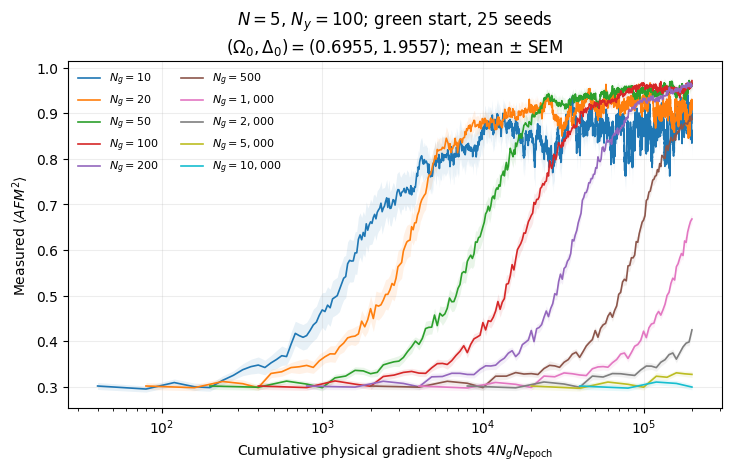

In [93]:
# GENERATES: performance_vs_gradient_shots_N5_green_init1_25seeds.pdf
# Run the bottom setup cell first; edit this plotting cell directly.
green_expectations = DATA_DIR / "green_trajectory_expectations_N5_25seeds.npz"
with load(green_expectations) as d:
    info = json.loads(str(d["metadata"]))
    assert N == 5 and info["N"] == 5 and info["N_y"] == N_Y
    assert info["complete"] and info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [0.6954632245521951, 1.9556663479392087])
    selected_ng = tuple(int(ng) for ng in d["N_g"])  # Edit to select curves.
    fig, ax = plt.subplots(figsize=(7.2, 4.6), layout="constrained")
    palette = plt.get_cmap("tab10")
    for i, ng in enumerate(selected_ng):
        epoch = d[f"epoch_Ng{ng}"]
        physical_shots = 4 * ng * epoch
        assert physical_shots[-1] == 200_000
        mean = d[f"measured_mean_Ng{ng}"]
        sem = d[f"measured_sem_Ng{ng}"]
        color = palette(i % 10)
        ax.plot(physical_shots, mean, color=color, lw=1.2, label=rf"$N_g={ng:,}$")
        ax.fill_between(physical_shots, mean-sem, mean+sem,
                        color=color, alpha=0.10, linewidth=0)
ax.set_xscale("log")  # Change to "linear" if preferred.
finish(ax, r"Cumulative physical gradient shots $4N_g N_{\rm epoch}$",
       r"Measured $\langle AFM^2\rangle$",
       r"$N=5$, $N_y=100$; green start, 25 seeds" + "\n" +
       r"$(\Omega_0,\Delta_0)=(0.6955,1.9557)$; mean $\pm$ SEM", legend=False)
ax.legend(ncol=2, frameon=False, fontsize=8, loc="upper left")
print("25 seeds at one green start; saved Ny=100 measurements; no smoothing.")
print("Cost is 4*Ng per epoch; Ny output shots excluded.")
print("Pre-update measurements use the current epoch's allocated gradient-shot cost.")
save_show(fig, "performance_vs_gradient_shots_N5_green_init1_25seeds")


# COMPLETED: Four purple-start figures — 25 seeds

All 250 purple-start cases and postprocessing completed successfully.
The purple paths use initial-set ID 5:
$(\Omega_0,\Delta_0)=(1.16771310144114,1.0853474197535722)$.
Run the **setup below**, then any of the four separate editable plotting cells.
The cached data are now available locally; no earlier notebook cells are needed.

The ten $N_g$ values, 25 seeds per value, $N_y=100$, $\beta=0.1$, learning rate
$0.01$, fixed $V=1$, budgets, and plotting settings match the green experiment.
Training retains the historical 100-step approximate state solver; exact
expectations are computed from the ground state at the learned parameters.
All expensive processing is outside the notebook; these cells only load and plot.

1. `time_budget_N5_purple_init5_25seeds.pdf` — pointwise 95% bootstrap bands.
2. `performance_measured_vs_exact_N5_purple_init5_25seeds.pdf`.
3. `performance_vs_epochs_N5_purple_init5_25seeds.pdf`.
4. `performance_vs_gradient_shots_N5_purple_init5_25seeds.pdf`.

The latter three use ±1 SEM across seeds, without smoothing. At epoch $k+1$,
the measured and exact curves use pre-update parameters $(\Omega_k,\Delta_k)$.
Gradient cost is $4N_g$ per epoch, excluding $N_y$ output shots; each pre-update
point is plotted at the current epoch's allocated cost. Time-budget endpoints
use post-update parameters after $\lfloor S/(4N_g)\rfloor$ updates.
Each cell saves a PDF and PNG without overwriting green-start figures.


In [1]:
# Run this setup once; the four following cells generate the four purple-start PDFs.
# This bottom section is independent of all earlier notebook cells.
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

_candidates = [
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "AFM_searching",
                      parent / "QEP_multiple_shot" / "AFM_searching")
]
STUDY_DIR = next(
    candidate.resolve() for candidate in _candidates
    if (candidate / "data" / "shots_2026-09-11" /
        "time_budget_purple_init5_N5_25seeds.npz").is_file()
)
DATA_DIR = STUDY_DIR / "data" / "shots_2026-09-11"
FIG_DIR = STUDY_DIR / "figures" / "shots_2026-09-11"
FIG_DIR.mkdir(parents=True, exist_ok=True)
N, N_Y = 5, 100
NG_GRID = (10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000)

def load(path):
    return np.load(path, allow_pickle=False)

def finish(ax, xlabel, ylabel, title=None, legend=True):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(alpha=0.22)
    if legend:
        ax.legend(frameon=False, fontsize=8)

def save_show(fig, stem):
    for suffix in (".pdf", ".png"):
        options = {"dpi": 180} if suffix == ".png" else {}
        path = FIG_DIR / f"{stem}{suffix}"
        fig.savefig(path, bbox_inches="tight", **options)
        print("Saved:", path)
    plt.show()

print("Purple-start data:", DATA_DIR)
print("Figure output:", FIG_DIR)




Purple-start data: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/data/shots_2026-09-11
Figure output: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11


25 seeds at the purple start; pointwise 95% bootstrap intervals.
Physical gradient-shot cap S=2B; Ny output shots excluded.
Historical 100-step training solver retained; exact endpoints.


Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/time_budget_N5_purple_init5_25seeds.pdf
Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/time_budget_N5_purple_init5_25seeds.png


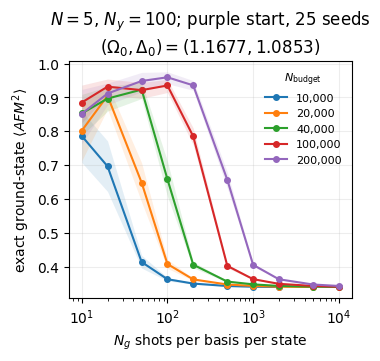

In [2]:
# GENERATES: time_budget_N5_purple_init5_25seeds.pdf
# Edit this cell directly; run the bottom setup cell first.
purple_summary = DATA_DIR / "time_budget_purple_init5_N5_25seeds.npz"
if not purple_summary.exists():
    raise FileNotFoundError(
        "Purple-start 25-seed results are not available locally yet. "
        "Wait for training/aggregation, then download the completed summary."
    )
with load(purple_summary) as d:
    info = json.loads(str(d["metadata"]))
    assert N == 5 and info["N"] == 5 and info["N_y"] == N_Y
    assert info["complete"] and info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [1.16771310144114, 1.0853474197535722])
    np.testing.assert_array_equal(d["N_g"], NG_GRID)
    ng_values, caps = d["N_g"], d["physical_budgets"]
    means, lo, hi = d["mean"], d["ci95_low"], d["ci95_high"]
fig, ax = plt.subplots(figsize=(3.5, 3.5), layout="constrained")
for b, cap in enumerate(caps):
    valid = np.isfinite(means[:, b])
    x = ng_values[valid]
    line, = ax.plot(x, means[valid, b], "o-", lw=1.5, ms=4, label=f"{cap:,}")
    ax.fill_between(x, lo[valid, b], hi[valid, b],
                    color=line.get_color(), alpha=0.12, linewidth=0)
ax.set_xscale("log")
finish(ax, r"$N_g$ shots per basis per state",
       r"exact ground-state $\langle AFM^2\rangle$",
       r"$N=5$, $N_y=100$; purple start, 25 seeds" + "\n" +
       r"$(\Omega_0,\Delta_0)=(1.1677,1.0853)$")
ax.legend(title=r"$N_{\mathrm{budget}}$", ncol=1, frameon=False,
          fontsize=8, title_fontsize=8)
print("25 seeds at the purple start; pointwise 95% bootstrap intervals.")
print("Physical gradient-shot cap S=2B; Ny output shots excluded.")
print("Historical 100-step training solver retained; exact endpoints.")
save_show(fig, "time_budget_N5_purple_init5_25seeds")




All available pre-update points; 25 seeds per Ng; no smoothing or new sampling.


Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_measured_vs_exact_N5_purple_init5_25seeds.pdf


Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_measured_vs_exact_N5_purple_init5_25seeds.png


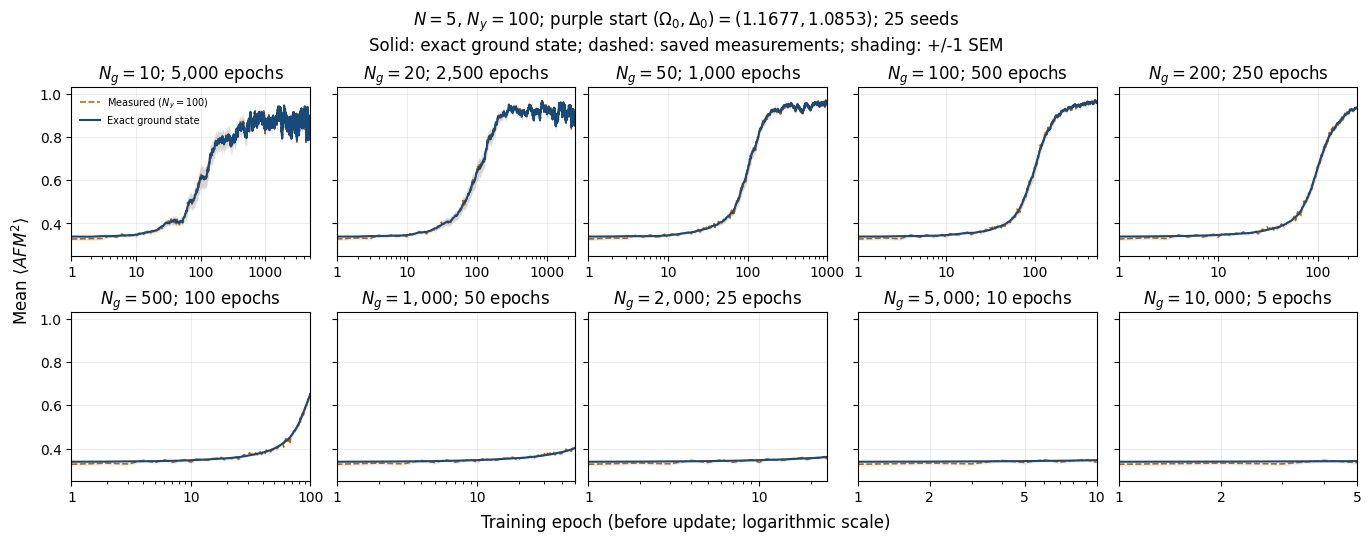

In [3]:
# GENERATES: performance_measured_vs_exact_N5_purple_init5_25seeds.pdf
# Edit this cell directly; run the bottom setup cell first.
purple_expectations = DATA_DIR / "purple_trajectory_expectations_N5_25seeds.npz"
with load(purple_expectations) as d:
    info = json.loads(str(d["metadata"]))
    assert N == 5 and info["N"] == 5 and info["N_y"] == N_Y
    assert info["complete"] and info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [1.16771310144114, 1.0853474197535722])
    from matplotlib.ticker import FuncFormatter, NullFormatter
    selected_ng = tuple(int(ng) for ng in d["N_g"])  # Edit to choose which panels to show.
    ncols = 5
    nrows = int(np.ceil(len(selected_ng) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13.6, 2.65*nrows),
                             sharey=True, squeeze=False, layout="constrained")
    for ax, ng in zip(axes.flat, selected_ng):
        epoch = d[f"epoch_Ng{ng}"]
        for name, color, style, label in (
            ("measured", "#C45E00", "--", rf"Measured ($N_y={N_Y}$)"),
            ("exact", "#174A78", "-", "Exact ground state"),
        ):
            mean = d[f"{name}_mean_Ng{ng}"]
            sem = d[f"{name}_sem_Ng{ng}"]
            ax.plot(epoch, mean, color=color, ls=style,
                    lw=1.15 if name == "measured" else 1.5, label=label)
            ax.fill_between(epoch, mean-sem, mean+sem, color=color, alpha=0.12, linewidth=0)
        ax.set(xscale="log", xlim=(1, int(epoch[-1])), ylim=(0.25, 1.03),
               title=rf"$N_g={ng:,}$; {len(epoch):,} epochs")
        ticks = ([1, 2, 5, 10] if epoch[-1] <= 10 else [1, 10, 100, 1000, 10000])
        ax.set_xticks([tick for tick in ticks if tick <= epoch[-1]])
        ax.xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"{value:g}"))
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.grid(alpha=0.22)
    for ax in list(axes.flat)[len(selected_ng):]:
        ax.set_visible(False)
    axes[0, 0].legend(frameon=False, fontsize=7, loc="upper left")
fig.supxlabel("Training epoch (before update; logarithmic scale)")
fig.supylabel(r"Mean $\langle AFM^2\rangle$")
fig.suptitle(r"$N=5$, $N_y=100$; purple start $(\Omega_0,\Delta_0)=(1.1677,1.0853)$; 25 seeds"
             + "\nSolid: exact ground state; dashed: saved measurements; shading: +/-1 SEM")
print("All available pre-update points; 25 seeds per Ng; no smoothing or new sampling.")
save_show(fig, "performance_measured_vs_exact_N5_purple_init5_25seeds")




All ten Ng values; each curve stops at its actual training length.


Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_epochs_N5_purple_init5_25seeds.pdf


Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_epochs_N5_purple_init5_25seeds.png


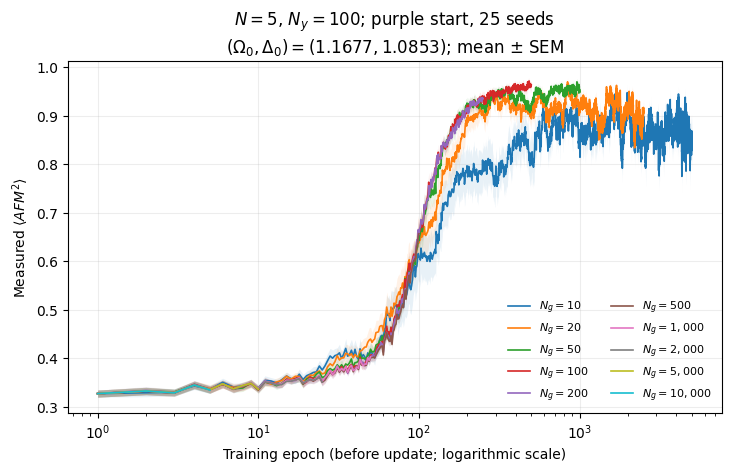

In [4]:
# GENERATES: performance_vs_epochs_N5_purple_init5_25seeds.pdf
# Edit this cell directly; run the bottom setup cell first.
purple_expectations = DATA_DIR / "purple_trajectory_expectations_N5_25seeds.npz"
with load(purple_expectations) as d:
    info = json.loads(str(d["metadata"]))
    assert N == 5 and info["N"] == 5 and info["N_y"] == N_Y
    assert info["complete"] and info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [1.16771310144114, 1.0853474197535722])
    selected_ng = tuple(int(ng) for ng in d["N_g"])  # Edit this tuple to select curves.
    fig, ax = plt.subplots(figsize=(7.2, 4.6), layout="constrained")
    palette = plt.get_cmap("tab10")
    for i, ng in enumerate(selected_ng):
        epoch = d[f"epoch_Ng{ng}"]
        mean, sem = d[f"measured_mean_Ng{ng}"], d[f"measured_sem_Ng{ng}"]
        color = palette(i % 10)
        ax.plot(epoch, mean, color=color, lw=1.2, label=rf"$N_g={ng:,}$")
        ax.fill_between(epoch, mean-sem, mean+sem, color=color, alpha=0.10, linewidth=0)
ax.set_xscale("log")  # Use "linear" if preferred.
finish(ax, "Training epoch (before update; logarithmic scale)",
       r"Measured $\langle AFM^2\rangle$",
       r"$N=5$, $N_y=100$; purple start, 25 seeds" + "\n" +
       r"$(\Omega_0,\Delta_0)=(1.1677,1.0853)$; mean $\pm$ SEM", legend=False)
ax.legend(ncol=2, frameon=False, fontsize=8, loc="lower right")
print("All ten Ng values; each curve stops at its actual training length.")
save_show(fig, "performance_vs_epochs_N5_purple_init5_25seeds")




25 seeds at one purple start; saved Ny=100 measurements; no smoothing.
Cost is 4*Ng per epoch; Ny output shots excluded.
Pre-update measurements use the current epoch's allocated gradient-shot cost.


Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_gradient_shots_N5_purple_init5_25seeds.pdf


Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_vs_gradient_shots_N5_purple_init5_25seeds.png


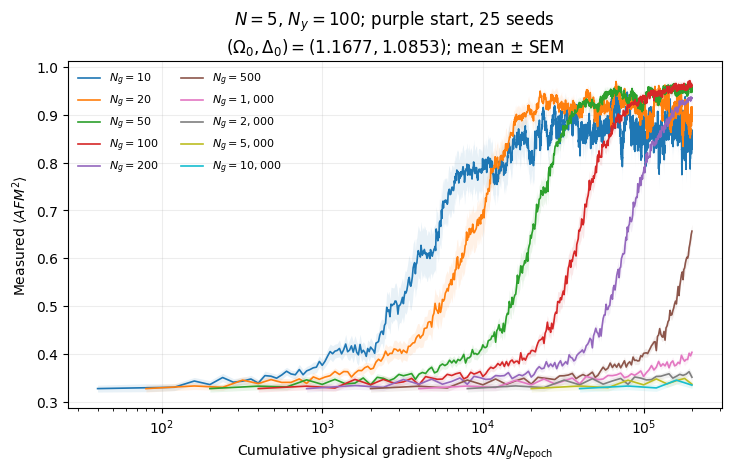

In [5]:
# GENERATES: performance_vs_gradient_shots_N5_purple_init5_25seeds.pdf
# Run the bottom setup cell first; edit this plotting cell directly.
purple_expectations = DATA_DIR / "purple_trajectory_expectations_N5_25seeds.npz"
with load(purple_expectations) as d:
    info = json.loads(str(d["metadata"]))
    assert N == 5 and info["N"] == 5 and info["N_y"] == N_Y
    assert info["complete"] and info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [1.16771310144114, 1.0853474197535722])
    selected_ng = tuple(int(ng) for ng in d["N_g"])  # Edit to select curves.
    fig, ax = plt.subplots(figsize=(7.2, 4.6), layout="constrained")
    palette = plt.get_cmap("tab10")
    for i, ng in enumerate(selected_ng):
        epoch = d[f"epoch_Ng{ng}"]
        physical_shots = 4 * ng * epoch
        assert physical_shots[-1] == 200_000
        mean = d[f"measured_mean_Ng{ng}"]
        sem = d[f"measured_sem_Ng{ng}"]
        color = palette(i % 10)
        ax.plot(physical_shots, mean, color=color, lw=1.2, label=rf"$N_g={ng:,}$")
        ax.fill_between(physical_shots, mean-sem, mean+sem,
                        color=color, alpha=0.10, linewidth=0)
ax.set_xscale("log")  # Change to "linear" if preferred.
finish(ax, r"Cumulative physical gradient shots $4N_g N_{\rm epoch}$",
       r"Measured $\langle AFM^2\rangle$",
       r"$N=5$, $N_y=100$; purple start, 25 seeds" + "\n" +
       r"$(\Omega_0,\Delta_0)=(1.1677,1.0853)$; mean $\pm$ SEM", legend=False)
ax.legend(ncol=2, frameon=False, fontsize=8, loc="upper left")
print("25 seeds at one purple start; saved Ny=100 measurements; no smoothing.")
print("Cost is 4*Ng per epoch; Ny output shots excluded.")
print("Pre-update measurements use the current epoch's allocated gradient-shot cost.")
save_show(fig, "performance_vs_gradient_shots_N5_purple_init5_25seeds")


Purple init5; means +/-1 SEM across 25 seeds; saved Ny=100 measurements.
Left: first 200 epochs (Ng1000/10000 stop at 50/5). Right: full available paths.
Shots=4*Ng*epoch, excluding Ny output shots; pre-update measurement at allocated cost.
Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_epochs_and_gradient_shots_N5_purple_init5_25seeds.pdf
Saved: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11/performance_epochs_and_gradient_shots_N5_purple_init5_25seeds.png


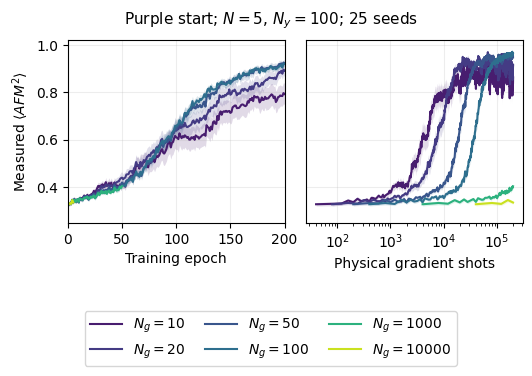

In [96]:
# NEW: Purple-start figures 3 and 4 in the requested side-by-side layout.
# Run bottom_purple_setup first. This cell loads cached data only.
# Left: first 200 epochs. Right: each run's full available gradient-shot range.
# Ng=1000 and 10000 have only 50 and 5 epochs; never pad or extrapolate them.
selected_ng = (10, 20, 50, 100, 1000, 10000)  # Existing gradient-shot counts; physical T=100.
epoch_window = 200  # Edit this to change the left panel's visible range.
full_palette = plt.get_cmap("viridis")(np.linspace(0.08, 0.92, len(NG_GRID)))
panel_colors = [full_palette[NG_GRID.index(ng)] for ng in selected_ng]
fig, axes = plt.subplots(1, 2, figsize=(5.2, 3.2), sharey=True)
fig.subplots_adjust(left=0.11, right=0.985, top=0.89, bottom=0.32, wspace=0.10)

with load(DATA_DIR / "purple_trajectory_expectations_N5_25seeds.npz") as d:
    info = json.loads(str(d["metadata"]))
    assert info["complete"] and info["N"] == 5 and info["N_y"] == 100
    assert info["seeds"] == 25 and info["initial_points"] == 1
    np.testing.assert_array_equal(info["point"], [1.16771310144114, 1.0853474197535722])
    for ng, color in zip(selected_ng, panel_colors):
        epoch = d[f"epoch_Ng{ng}"]
        mean, sem = d[f"measured_mean_Ng{ng}"], d[f"measured_sem_Ng{ng}"]
        visible = epoch <= epoch_window
        axes[0].plot(epoch[visible], mean[visible], color=color, lw=1.5,
                     label=rf"$N_g={ng}$")
        axes[0].fill_between(epoch[visible], (mean-sem)[visible], (mean+sem)[visible],
                             color=color, alpha=0.16, linewidth=0)
        shots = 4 * ng * epoch  # Physical gradient shots; excludes Ny output shots.
        axes[1].plot(shots, mean, color=color, lw=1.5)
        axes[1].fill_between(shots, mean-sem, mean+sem,
                             color=color, alpha=0.16, linewidth=0)

axes[0].set(xlim=(0, epoch_window), ylim=(0.25, 1.02),
            xlabel="Training epoch",
            ylabel=r"Measured $\langle AFM^2\rangle$")
axes[0].set_xticks(np.linspace(0, epoch_window, 5))
axes[1].set(xscale="log", xlabel="Physical gradient shots")
axes[1].tick_params(axis="y", left=False)
for ax in axes:
    ax.grid(alpha=0.22)
    ax.tick_params(labelsize=10)
fig.suptitle(r"Purple start; $N=5$, $N_y=100$; 25 seeds", fontsize=11, y=0.985)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.15),
           ncol=3, frameon=True, fontsize=10, columnspacing=1.4, handlelength=2.3)
print("Purple init5; means +/-1 SEM across 25 seeds; saved Ny=100 measurements.")
print("Left: first 200 epochs (Ng1000/10000 stop at 50/5). Right: full available paths.")
print("Shots=4*Ng*epoch, excluding Ny output shots; pre-update measurement at allocated cost.")
save_show(fig, "performance_epochs_and_gradient_shots_N5_purple_init5_25seeds")
